In [103]:
!pip install pymupdf nltk requests
!pip install paho-mqtt requests matplotlib

In [104]:
# Core dependencies
import re
import fitz  # PyMuPDF
import requests
from collections import defaultdict
from nltk.stem import PorterStemmer
import matplotlib.pyplot as plt
from IPython.display import HTML, display

In [105]:

import os, glob, sys, subprocess
try:
    import gdown
except ImportError:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "gdown"], check=False)
    import gdown

DRIVE_FOLDER_URL = "https://drive.google.com/drive/folders/1FfLT9U8AKaxLAWY02MhNeS-ZhlJqjo2N"

LOCAL_DIR = "/content/papers"
os.makedirs(LOCAL_DIR, exist_ok=True)

gdown.download_folder(DRIVE_FOLDER_URL, output=LOCAL_DIR, quiet=False, use_cookies=False)

pdf_paths = sorted(glob.glob(os.path.join(LOCAL_DIR, "**", "*.pdf"), recursive=True))
assert pdf_paths, (
    f"No PDFs downloaded into {LOCAL_DIR}. "
    "Check that the Drive folder is shared"
)

# Build the article list from the downloaded files
ARTICLES = []
for i, p in enumerate(pdf_paths, start=1):
    title = os.path.splitext(os.path.basename(p))[0]
    ARTICLES.append({"doc_id": f"doc{i}", "title": title, "url": p})

DOC_LINKS = {a["doc_id"]: a["url"] for a in ARTICLES}
DOC_TITLES = {a["doc_id"]: a["title"] for a in ARTICLES}
DOC_TEXT = {}

print(f"\nDownloaded {len(ARTICLES)} PDF(s):")
for a in ARTICLES:
    print(f"  {a['doc_id']}: {a['title']}")


Retrieving folder contents


Processing file 1zzpXQeEFkmLytrY0KOd4F7xNBSo_wdwx Anthracnose disease of Swiss cheese plant [Monstera deliciosa Liebm.].pdf
Processing file 1vsWtMF_T564HLLcj6VOb68FMtcuII6FV In vitro Antioxidant Activity and Total Phenolic Content of Monstera.pdf
Processing file 1Q-_9E9D80worlxjm068pXRD17LTYdHdf Influence of some chemical compounds as.pdf
Processing file 1BR6XI0PmJu2IVtJetmr4bghi4YpJOxkx Micropropagation and Acclimatization of Monstera deliciosa Liebm. ‘Thai Constellation.pdf
Processing file 1MwQyqNqKuP-sTB69qCwGbHQGQB0G0pXA Phytochemistry and pharmacological potential of.pdf


Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From: https://drive.google.com/uc?id=1zzpXQeEFkmLytrY0KOd4F7xNBSo_wdwx
To: /content/papers/Anthracnose disease of Swiss cheese plant [Monstera deliciosa Liebm.].pdf
100%|██████████| 483k/483k [00:00<00:00, 36.3MB/s]
Downloading...
From: https://drive.google.com/uc?id=1vsWtMF_T564HLLcj6VOb68FMtcuII6FV
To: /content/papers/In vitro Antioxidant Activity and Total Phenolic Content of Monstera.pdf
100%|██████████| 358k/358k [00:00<00:00, 13.9MB/s]
Downloading...
From: https://drive.google.com/uc?id=1Q-_9E9D80worlxjm068pXRD17LTYdHdf
To: /content/papers/Influence of some chemical compounds as.pdf
100%|██████████| 341k/341k [00:00<00:00, 31.8MB/s]
Downloading...
From: https://drive.google.com/uc?id=1BR6XI0PmJu2IVtJetmr4bghi4YpJOxkx
To: /content/papers/Micropropagation and Acclimatization of Monstera deliciosa Liebm. ‘Thai Constellation.pdf
100%|██████████| 1.27M/1.27M [00:00<0


Downloaded 5 PDF(s):
  doc1: Anthracnose disease of Swiss cheese plant [Monstera deliciosa Liebm.]
  doc2: In vitro Antioxidant Activity and Total Phenolic Content of Monstera
  doc3: Influence of some chemical compounds as
  doc4: Micropropagation and Acclimatization of Monstera deliciosa Liebm. ‘Thai Constellation
  doc5: Phytochemistry and pharmacological potential of



Download completed


In [106]:
HEADERS = {"User-Agent": "Mozilla/5.0"}

def fetch_pdf_text(source):
    # Extract and normalize text from local or remote PDF
    if isinstance(source, str) and source.lower().startswith("http"):
        resp = requests.get(source, headers=HEADERS, timeout=30)
        resp.raise_for_status()
        doc = fitz.open(stream=resp.content, filetype="pdf")
    else:
        doc = fitz.open(source)
    text = " ".join(page.get_text() for page in doc)
    doc.close()
    return re.sub(r"\s+", " ", text).strip()

In [107]:
STOP_WORDS = {
    "a", "an", "the", "and", "or", "of", "to", "in", "on", "for", "with",
    "as", "by", "is", "are", "was", "were", "be", "been", "that", "this",
    "these", "those", "we", "our", "it", "its", "from", "at", "which",
    "can", "using", "used", "study", "paper", "results", "method", "based",
    "show", "shows", "each", "such", "yet", "also", "may", "between",
}

## **Text processing**

In [108]:

stemmer = PorterStemmer()

def tokenize(text):
    # lowercase alphabetic tokens only
    return re.findall(r"[a-z]+", text.lower())

def clean_tokens(tokens):
    return [stemmer.stem(t) for t in tokens
            if t not in STOP_WORDS and len(t) > 2]


In [109]:
# significant words we chose to index

INDEX_TERMS = {
    "monstera", "deliciosa", "anthracnose", "colletotrichum", "gloeosporioides",
    "conidia", "acervuli", "pathogenicity", "infection", "antioxidant",
    "scavenging", "radical", "ascorbic", "phenolic", "superoxide",
    "glycerol", "transpiration", "catalase", "pigments", "proteins",
    "micropropagation", "acclimatization", "bioreactor", "biostimulant",
    "chlorophyll", "multiplication", "pharmacological", "flavonoids",
    "antibacterial", "bioactive",
}

INDEX_TERMS = {stemmer.stem(w) for w in INDEX_TERMS}

In [110]:
def build_index(articles):
    # Generate inverted index and frequency map from article collection
    postings = defaultdict(set)
    freq = defaultdict(int)

    for art in articles:
        doc_id = art["doc_id"]
        try:
            text = fetch_pdf_text(art["url"])
        except Exception as e:
            print(f"Skipped {doc_id}: {e}")
            continue

        DOC_TEXT[doc_id] = text
        print(f"Indexed {doc_id}: {len(text)} chars")
        for term in clean_tokens(tokenize(text)):
            if term not in INDEX_TERMS:
                continue
            postings[term].add(doc_id)
            freq[(term, doc_id)] += 1

    index = [
        {
            "term": t,
            "DocIDs": sorted(d),
            "doc_freq": {doc: freq[(t, doc)] for doc in sorted(d)},
            "total_freq": sum(freq[(t, doc)] for doc in d),
        }
        for t, d in sorted(postings.items())
    ]
    return index, freq

index, freq = build_index(ARTICLES)
print(f"Total unique terms: {len(index)}")

Indexed doc1: 18123 chars
Indexed doc2: 17604 chars
Indexed doc3: 29012 chars
Indexed doc4: 39772 chars
Indexed doc5: 39643 chars
Total unique terms: 30


In [111]:
# Synchronize search index with Firebase
DB_URL = "https://cloud-course-9c4ad-default-rtdb.europe-west1.firebasedatabase.app/"
index_dict = {entry["term"]: entry for entry in index}
resp = requests.put(f"{DB_URL}/plant_disease_index.json", json=index_dict)
print("Index saved" if resp.ok else f"Error: {resp.text}")

Index saved


In [112]:
saved = requests.get(f"{DB_URL}/plant_disease_index.json").json()
print(f"Read {len(saved)} terms back from Firebase")
next(iter(saved.items()))

Read 30 terms back from Firebase


('acclimat',
 {'DocIDs': ['doc4'],
  'doc_freq': {'doc4': 25},
  'term': 'acclimat',
  'total_freq': 25})

In [113]:
lookup = {entry["term"]: entry["DocIDs"] for entry in index}

def search(query):
    """Return docs sorted by query-term matches, then by total frequency."""
    terms = clean_tokens(tokenize(query))
    scores = defaultdict(lambda: {"matches": 0, "freq": 0})
    for term in terms:
        for doc_id in lookup.get(term, []):
            scores[doc_id]["matches"] += 1
            scores[doc_id]["freq"] += freq[(term, doc_id)]
    return sorted(scores.items(),
                  key=lambda x: (x[1]["matches"], x[1]["freq"]),
                  reverse=True)

search("monstera deliciosa anthracnose colletotrichum gloeosporioides")

[('doc1', {'matches': 5, 'freq': 104}),
 ('doc5', {'matches': 2, 'freq': 138}),
 ('doc4', {'matches': 2, 'freq': 54}),
 ('doc2', {'matches': 2, 'freq': 29}),
 ('doc3', {'matches': 2, 'freq': 26})]

In [114]:
def rag_display(query):
    """Render an enriched result card per matching document."""
    ranked = search(query)
    if not ranked:
        display(HTML(f"<p>No documents matched <b>{query}</b>.</p>"))
        return

    cards = [f"<h3>Results for: {query}</h3>"]
    for doc_id, s in ranked:
        snippet = DOC_TEXT.get(doc_id, "")[:200].strip() + "..."
        cards.append(f"""
        <div style="border:1px solid #ccc;border-radius:8px;padding:12px;margin:8px 0;">
          <a href="{DOC_LINKS[doc_id]}" target="_blank"
             style="font-size:16px;font-weight:bold;text-decoration:none;">
             {DOC_TITLES[doc_id]}</a>
          <div style="color:#555;font-size:12px;margin:4px 0;">
             {doc_id} | matched terms: {s['matches']} | score: {s['freq']}</div>
          <div style="font-size:13px;">{snippet}</div>
        </div>
        """)
    display(HTML("".join(cards)))

rag_display("monstera deliciosa anthracnose colletotrichum gloeosporioides")

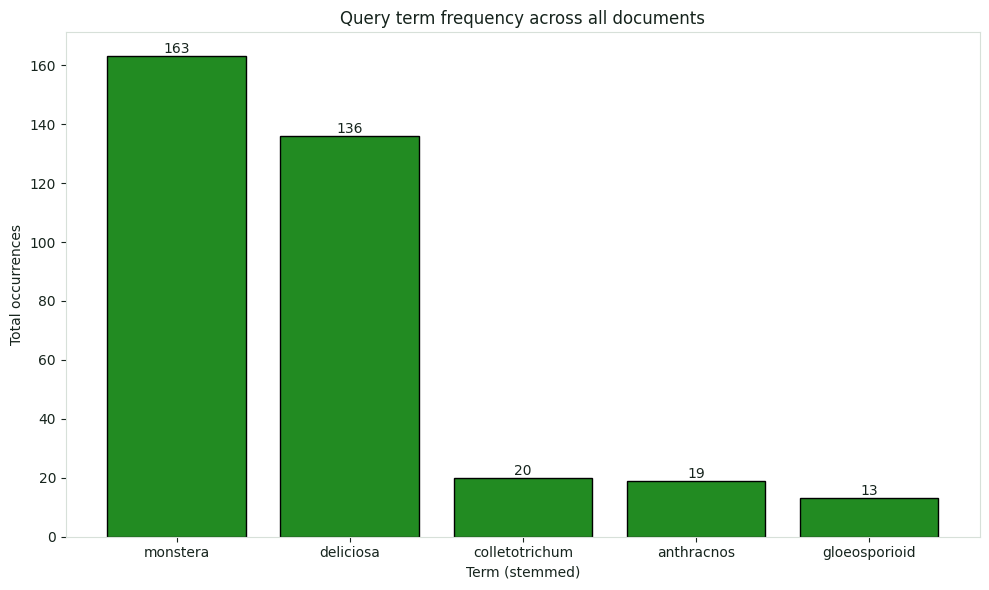

In [115]:
def plot_query_frequencies(query):
    """Bar chart of how often each query term appears across all documents"""
    terms = clean_tokens(tokenize(query))
    totals = {t: sum(freq[(t, d)] for d in lookup.get(t, [])) for t in terms}
    totals = {t: c for t, c in totals.items() if c > 0}
    if not totals:
        print("No query terms found in the index.")
        return

    items = sorted(totals.items(), key=lambda x: x[1], reverse=True)
    words, counts = zip(*items)

    plt.figure(figsize=(10, 6))
    bars = plt.bar(words, counts, color="forestgreen", edgecolor="black")
    plt.title("Query term frequency across all documents")
    plt.xlabel("Term (stemmed)")
    plt.ylabel("Total occurrences")
    for bar, c in zip(bars, counts):
        plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
                 str(c), ha="center", va="bottom")
    plt.tight_layout()
    plt.show()

plot_query_frequencies("monstera deliciosa anthracnose colletotrichum gloeosporioides")

In [116]:
# ---- Gemini LLM (REST API) ----
import base64

GEMINI_MODEL = "gemini-3.1-flash-lite"
try:
    from google.colab import userdata
    GEMINI_API_KEY = userdata.get("GEMINI_API_KEY")
except Exception:
    GEMINI_API_KEY = "AQ.Ab8RN6LCfYJbmaW3pdU2-OeCNwAsL27WyvWYMM_jN6MKZqom6Q"

_GEMINI_URL = ("https://generativelanguage.googleapis.com/v1beta/"
               f"models/{GEMINI_MODEL}:generateContent")

def gemini(prompt, system=None, history=None, image_bytes=None,
           image_mime="image/jpeg", temperature=0.4, max_tokens=800):
    """One Gemini call. history = list of {'role':'user'|'model','text':...}.
    Returns the answer text, or an explanatory string on error."""
    if not GEMINI_API_KEY:
        return ("[Gemini key missing. In Colab: open the key icon in the left "
                "sidebar, add a secret named GEMINI_API_KEY, then re-run this cell.]")
    contents = [{"role": h["role"], "parts": [{"text": h["text"]}]}
                for h in (history or [])]
    parts = [{"text": prompt}]
    if image_bytes is not None:
        parts.append({"inline_data": {"mime_type": image_mime,
                      "data": base64.b64encode(image_bytes).decode()}})
    contents.append({"role": "user", "parts": parts})
    body = {"contents": contents, "generationConfig": {"temperature": temperature, "maxOutputTokens": max_tokens}}
    if system:
        body["systemInstruction"] = {"parts": [{"text": system}]}
    try:
        r = requests.post(_GEMINI_URL, params={"key": GEMINI_API_KEY},
                          json=body, timeout=60)
        r.raise_for_status()
        return r.json()["candidates"][0]["content"]["parts"][0]["text"]
    except Exception as e:
        return f"[Gemini error: {e}]"

def _md_to_html(text):
    """Tiny markdown -> HTML: bold, bullets, line breaks. Enough for LLM output."""
    import html as _html
    lines = []
    for line in _html.escape(text).split("\n"):
        s = line.strip()
        if s.startswith("* ") or s.startswith("- "):
            lines.append("&bull; " + s[2:])
        else:
            lines.append(line)
    joined = "<br>".join(lines)
    return re.sub(r"\*\*(.+?)\*\*", r"<b>\1</b>", joined)


def gemini_stream(prompt, system=None, history=None, image_bytes=None,
                  image_mime="image/jpeg", temperature=0.4, max_tokens=800):
    """Yield text chunks from Gemini as they stream in (Server-Sent Events), so
    the UI can show the answer as it is written instead of after it finishes."""
    if not GEMINI_API_KEY:
        yield "[Gemini key missing. Add GEMINI_API_KEY in Colab secrets and re-run this cell.]"
        return
    contents = [{"role": h["role"], "parts": [{"text": h["text"]}]}
                for h in (history or [])]
    parts = [{"text": prompt}]
    if image_bytes is not None:
        parts.append({"inline_data": {"mime_type": image_mime,
                      "data": base64.b64encode(image_bytes).decode()}})
    contents.append({"role": "user", "parts": parts})
    body = {"contents": contents,
            "generationConfig": {"temperature": temperature, "maxOutputTokens": max_tokens}}
    if system:
        body["systemInstruction"] = {"parts": [{"text": system}]}
    url = _GEMINI_URL.replace(":generateContent", ":streamGenerateContent")
    try:
        with requests.post(url, params={"key": GEMINI_API_KEY, "alt": "sse"},
                           json=body, stream=True, timeout=120) as r:
            r.raise_for_status()
            for line in r.iter_lines():
                if not line:
                    continue
                line = line.decode("utf-8")
                if not line.startswith("data:"):
                    continue
                try:
                    chunk = json.loads(line[5:].strip())
                    yield chunk["candidates"][0]["content"]["parts"][0]["text"]
                except Exception:
                    continue
    except Exception as e:
        yield f"[Gemini error: {e}]"


In [117]:
# ---- LLM RAG: grounded answers from the indexed papers ----
def rag_context(query, k=3, chars=2800):
    """Retrieve top documents with the keyword index and build the grounded
    (system, prompt, sources). Returns (None, None, []) if nothing matches."""
    ranked = search(query)
    if not ranked:
        return None, None, []
    top = ranked[:k]
    context = ""
    for doc_id, _ in top:
        excerpt = DOC_TEXT.get(doc_id, "")[:chars]
        context += f"\n--- ARTICLE: {DOC_TITLES[doc_id]} ---\n{excerpt}\n"
    system = ("You are a Monstera deliciosa plant-disease research assistant. "
              "Answer the question using ONLY the article excerpts provided. "
              "Cite the article titles you used in [brackets]. "
              "If the excerpts do not contain the answer, say so plainly.")
    prompt = f"Question: {query}\n\nArticle excerpts:{context}"
    return system, prompt, top

def rag_answer(query, k=3, chars=2800):
    """Non-streaming convenience wrapper around rag_context + gemini."""
    system, prompt, top = rag_context(query, k, chars)
    if system is None:
        return None, []
    return gemini(prompt, system=system, temperature=0.2), top


### **SCREENS AND IOT**

In [118]:
import json
import random
import datetime
import requests
import ipywidgets as widgets
import matplotlib.pyplot as plt
import paho.mqtt.client as mqtt
from IPython.display import display, Image, clear_output

In [119]:
# Realtime DB
DB_URL = "https://cloud-course-9c4ad-default-rtdb.europe-west1.firebasedatabase.app"

# Live IoT sensor server
SENSOR_SERVER = "https://server-cloud-v645.onrender.com/"

# Free public MQTT broker
MQTT_BROKER = "broker.hivemq.com"
MQTT_PORT = 1883
TEAM = "braude-team-chameleon"
MQTT_TOPIC = f"braude/plant/{TEAM}"

SENSOR_LOG = []     # readings, shared by sensor + dashboard screens
MQTT_MESSAGES = []  # messages received from the broker

# Healthy ranges, used by the dashboard to decide plant status
HEALTHY = {
    "temperature": (18, 30),   # Celsius
    "humidity": (40, 70),      # percent
    "soil_moisture": (30, 70), # percent
    "leaf_wetness": (0, 40),   # percent
}

In [120]:
def on_connect(client, userdata, flags, rc):
    client.subscribe(MQTT_TOPIC)
    print(f"MQTT connected (rc={rc}), subscribed to {MQTT_TOPIC}")

def on_message(client, userdata, msg):
    # background thread: only append
    try:
        payload = json.loads(msg.payload.decode())
    except Exception:
        payload = msg.payload.decode()
    MQTT_MESSAGES.append({"topic": msg.topic, "payload": payload})

# paho-mqtt 2.x needs the callback API version; fall back for 1.x
try:
    mqtt_client = mqtt.Client(mqtt.CallbackAPIVersion.VERSION1)
except (AttributeError, TypeError):
    mqtt_client = mqtt.Client()

mqtt_client.on_connect = on_connect
mqtt_client.on_message = on_message

try:
    mqtt_client.connect(MQTT_BROKER, MQTT_PORT, keepalive=60)
    mqtt_client.loop_start()  # background network thread
except Exception as e:
    print(f"MQTT connection failed: {e}")
    mqtt_client = None

def mqtt_publish(reading):
    """Publish one reading to the team topic. Safe if broker is down."""
    if mqtt_client is None:
        return
    try:
        mqtt_client.publish(MQTT_TOPIC, json.dumps(reading))
    except Exception as e:
        print(f"MQTT publish skipped: {e}")


/tmp/ipykernel_8841/2180815894.py:15: DeprecationWarning: Callback API version 1 is deprecated, update to latest version
  mqtt_client = mqtt.Client(mqtt.CallbackAPIVersion.VERSION1)


In [121]:
# Server feed names for each of our fields (None = no server feed, use local estimate)
_FEED_MAP = {
    "temperature": "temperature",
    "humidity":    "humidity",
    "soil_moisture": "soil",
    "leaf_wetness":  None,
}
_FEED_FALLBACK = {
    "temperature":  (15, 35),
    "humidity":     (30, 80),
    "soil_moisture":(20, 80),
    "leaf_wetness": (0,  60),
}

def read_sensors():
    """Fetch the latest value for each metric from the cloud server.
    Falls back to a random value for any metric that is unreachable or missing."""
    now = datetime.datetime.now()
    result = {"timestamp": now.strftime("%H:%M:%S"), "dt": now.isoformat(timespec="seconds")}
    for field, feed in _FEED_MAP.items():
        lo, hi = _FEED_FALLBACK[field]
        if feed is None:
            result[field] = round(random.uniform(lo, hi), 1)
            continue
        try:
            resp = requests.get(
                f"{SENSOR_SERVER}/history",
                params={"feed": feed, "limit": 1},
                timeout=10,
            )
            data = resp.json()
            if "data" in data and data["data"]:
                result[field] = round(float(data["data"][0]["value"]), 1)
            else:
                result[field] = round(random.uniform(lo, hi), 1)
        except Exception:
            result[field] = round(random.uniform(lo, hi), 1)
    return result

def load_history(limit=20, replace=False):
    """Fetch the last `limit` readings per feed from the server and populate SENSOR_LOG.
    If replace=True, always fetches fresh data. If replace=False, skips when SENSOR_LOG is non-empty."""
    global SENSOR_LOG
    if not replace and SENSOR_LOG:
        return 0

    feeds = {
        "temperature": "temperature",
        "humidity":    "humidity",
        "soil_moisture": "soil",
    }
    raw = {}
    for field, feed in feeds.items():
        try:
            resp = requests.get(
                f"{SENSOR_SERVER}/history",
                params={"feed": feed, "limit": limit},
                timeout=15,
            )
            result = resp.json()
            if "data" in result and result["data"]:
                raw[field] = result["data"]  # newest-first from server
        except Exception:
            pass

    if not raw:
        return 0

    ref_key = next(iter(raw))
    n = min(len(v) for v in raw.values())
    entries = []
    for i in range(n):
        ts_str = raw[ref_key][i].get("created_at", "")
        dt_iso = ""
        try:
            _dt = datetime.datetime.fromisoformat(
                ts_str.replace("Z", "+00:00").replace(" UTC", "+00:00")
            )
            ts = _dt.strftime("%H:%M:%S")
            dt_iso = _dt.isoformat(timespec="seconds")
        except Exception:
            ts = ts_str[:8] if len(ts_str) >= 8 else str(i)

        entry = {"timestamp": ts, "dt": dt_iso}
        for field in feeds:
            if field in raw and i < len(raw[field]):
                try:
                    entry[field] = round(float(raw[field][i]["value"]), 1)
                except Exception:
                    lo, hi = _FEED_FALLBACK[field]
                    entry[field] = round(random.uniform(lo, hi), 1)
            else:
                lo, hi = _FEED_FALLBACK[field]
                entry[field] = round(random.uniform(lo, hi), 1)

        lo, hi = _FEED_FALLBACK["leaf_wetness"]
        entry["leaf_wetness"] = round(random.uniform(lo, hi), 1)
        entries.append(entry)

    entries.reverse()  # convert to chronological order (oldest first)
    if replace:
        SENSOR_LOG.clear()
    SENSOR_LOG.extend(entries)
    return len(entries)

def push_to_firebase(reading):
    """Store one reading in the Firebase Realtime DB. Safe to skip if offline."""
    try:
        requests.post(f"{DB_URL}/sensor_readings.json", json=reading, timeout=10)
    except Exception as e:
        print(f"Firebase push skipped: {e}")

In [122]:
CHAMELEON_IMG = (
    "<img src='https://i.postimg.cc/8knfcPDn/Chameleon-icon.png'"
    " style='width:38px;height:38px;object-fit:contain;' />"
)

In [123]:
# Gamification engine state and logic
GAME = {"points": 0, "actions": 0, "badges": []}
BADGES = [(10, "Seedling"), (40, "Sprout"), (100, "Gardener"),
          (200, "Botanist"), (400, "Plant Whisperer")]
NEW_BADGES = []

def _load_game():
    # Initialize local state from Firebase
    try:
        saved = requests.get(f"{DB_URL}/gamification.json", timeout=8).json()
        if isinstance(saved, dict):
            GAME.update({"points": saved.get("points", 0),
                         "actions": saved.get("actions", 0),
                         "badges": saved.get("badges", []) or []})
    except Exception:
        pass

def award(points, reason="", persist=True):
    # Update score, unlock badges, and persist to cloud
    GAME["points"] += points
    GAME["actions"] += 1
    NEW_BADGES.clear()
    for thr, name in BADGES:
        if GAME["points"] >= thr and name not in GAME["badges"]:
            GAME["badges"].append(name)
            NEW_BADGES.append(name)
    if persist:
        try:
            requests.put(f"{DB_URL}/gamification.json", json=GAME, timeout=5)
        except Exception:
            pass
    return GAME

_load_game()

In [124]:
# ---- Image search over a HuggingFace leaf dataset (CLIP nearest-neighbor) ----
# Upload a Monstera leaf photo; we embed it with CLIP and find the most similar
# reference leaves in a HF dataset, then report healthy vs diseased by majority.
# ponytail: small known dataset + sampled subset; swap HF_DATASET / raise
# SAMPLE_PER_CLASS for broader coverage. Falls back to Gemini vision if HF fails.
HF_DATASET = "AI-Lab-Makerere/beans"   # classes: healthy, angular_leaf_spot, bean_rust
SAMPLE_PER_CLASS = 40
_HF = {"ready": False, "model": None, "emb": None, "labels": [], "names": {}}

def _hf_init():
    """Lazily install deps, download a dataset sample, embed it once with CLIP."""
    if _HF["ready"]:
        return True
    try:
        import numpy as np
        from datasets import load_dataset
        from sentence_transformers import SentenceTransformer
    except Exception:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                        "datasets", "sentence-transformers"], check=False)
        import numpy as np
        from datasets import load_dataset
        from sentence_transformers import SentenceTransformer
    try:
        ds = load_dataset(HF_DATASET, split="train")
        names = ds.features["labels"].names
        _HF["names"] = {i: n for i, n in enumerate(names)}
        per = {i: 0 for i in range(len(names))}
        imgs, labels = [], []
        for row in ds:
            lab = row["labels"]
            if per[lab] >= SAMPLE_PER_CLASS:
                continue
            imgs.append(row["image"].convert("RGB"))
            labels.append(lab)
            per[lab] += 1
            if all(c >= SAMPLE_PER_CLASS for c in per.values()):
                break
        model = SentenceTransformer("clip-ViT-B-32")
        emb = model.encode(imgs, convert_to_numpy=True, normalize_embeddings=True)
        _HF.update({"ready": True, "model": model, "emb": emb, "labels": labels})
        return True
    except Exception as e:
        _HF["error"] = str(e)
        return False

def hf_image_search(image_bytes, top=5):
    """Return [(label_name, similarity)] of nearest dataset leaves, or None on failure."""
    if not _hf_init():
        return None
    import numpy as np
    from PIL import Image as PILImage
    img = PILImage.open(io.BytesIO(image_bytes)).convert("RGB")
    q = _HF["model"].encode([img], convert_to_numpy=True, normalize_embeddings=True)[0]
    sims = _HF["emb"] @ q
    idx = np.argsort(-sims)[:top]
    return [(_HF["names"][_HF["labels"][i]], float(sims[i])) for i in idx]

def hf_image_report(image_bytes):
    """HTML report: nearest dataset matches plus a healthy/diseased verdict.
    Falls back to a Gemini vision description if the dataset path is unavailable."""
    matches = hf_image_search(image_bytes)
    if matches is None:
        verdict = gemini("Describe this plant leaf and whether it looks healthy or "
                         "diseased. Be brief.", image_bytes=image_bytes)
        return (f"<div class='note'>Dataset search unavailable "
                f"({_HF.get('error','')}); used the vision model instead.</div>"
                f"<div class='rag-answer'>{_md_to_html(verdict)}</div>")
    healthy = sum(1 for n, _ in matches if "healthy" in n.lower())
    verdict = "looks HEALTHY" if healthy > len(matches) / 2 else "shows possible DISEASE"
    rows = "".join(
        f"<div class='ro-item'><span class='ro-k'>{n.replace('_', ' ')}</span>"
        f"<span class='ro-v'>{s:.2f}</span></div>" for n, s in matches)
    return (f"<div class='ro-title'>Closest reference leaves in {HF_DATASET}</div>"
            f"<div class='ro-grid'>{rows}</div>"
            f"<div class='note'>Majority of nearest matches indicates the leaf "
            f"<b>{verdict}</b>. Reference dataset: {HF_DATASET} (no accuracy guarantee).</div>")


import base64, threading

def hf_warm_async():
    """Warm the dataset + CLIP model in the background so uploads are snappy."""
    if not _HF["ready"]:
        threading.Thread(target=_hf_init, daemon=True).start()

def leaf_vision_verdict(image_bytes):
    """Fast primary assessment via Gemini vision (no local model needed)."""
    return gemini(
        "You are a houseplant doctor specializing in Monstera deliciosa. "
        "Assess this leaf photo. Respond EXACTLY in this format:\n"
        "STATUS: Healthy or Watch or Diseased\n"
        "SUMMARY: one short sentence on what you see\n"
        "TIPS:\n- short care action\n- short care action",
        image_bytes=image_bytes, temperature=0.3)

def _parse_status(text):
    m = re.search(r"STATUS:\s*([A-Za-z]+)", text or "")
    s = m.group(1).capitalize() if m else "Watch"
    return s if s in ("Healthy", "Watch", "Diseased") else "Watch"

def _img_data_uri(content):
    mime = "image/png" if content[:8] == b"\x89PNG\r\n\x1a\n" else "image/jpeg"
    return f"data:{mime};base64,{base64.b64encode(content).decode()}"

def hf_matches_html(matches):
    """Render the nearest reference leaves as labelled chips. Empty if unavailable."""
    if not matches:
        return ""
    healthy = sum(1 for n, _ in matches if "healthy" in n.lower())
    tone = "ok" if healthy > len(matches) / 2 else "warn"
    chips = "".join(f"<span class='lf-chip {tone}'>{n.replace('_', ' ')} "
                    f"<b>{s:.2f}</b></span>" for n, s in matches)
    return ("<div class='lf-ds'><div class='lf-ds-title'>Closest reference leaves</div>"
            f"<div class='lf-chips'>{chips}</div></div>")


# Load the reference dataset + model now, before the app, so the in-app leaf
# comparison is instant and users never see a download or a technical control.
print("Loading leaf reference dataset and model (one-time, about a minute)...")
if _hf_init():
    print(f"Reference dataset ready: {len(_HF['labels'])} reference leaves embedded.")
else:
    print(f"Reference dataset unavailable ({_HF.get('error', '')}); the leaf health "
          "check will still work using the vision model.")


Loading leaf reference dataset and model (one-time, about a minute)...
MQTT connected (rc=0), subscribed to braude/plant/braude-team-chameleon


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

Reference dataset ready: 120 reference leaves embedded.


In [125]:
# ---- Agentic plant-care assistant: an LLM that chooses tools in a loop ----
# This is a real agent, not the one-shot chatbot or the fixed retrieve-then-answer
# RAG: it is given a GOAL and a TOOLBOX, and on each step Gemini decides which tool
# to call, we run it, feed the observation back, and loop until it returns a final
# answer (ReAct pattern). It can also ACT on the plant (change the watering schedule).
import json, re

def _tool_get_readings(_=None):
    """Read the live sensors and flag any metric outside its healthy range."""
    r = read_sensors()
    issues = [f"{k}={r[k]} (healthy {lo}-{hi})"
              for k, (lo, hi) in HEALTHY.items()
              if k in r and not (lo <= r[k] <= hi)]
    r["out_of_range"] = issues or ["all metrics within healthy range"]
    return r

def _tool_lookup_disease(query):
    """Search the indexed Monstera papers for a symptom/disease (grounded RAG)."""
    ans, _top = rag_answer(str(query))
    return ans or "No matching article found in the index."

def _tool_set_watering(hours):
    """ACT: change the shared watering interval used by the Care screen."""
    try:
        WATERING["interval_hours"] = int(float(hours))
        return f"Watering interval set to every {WATERING['interval_hours']}h."
    except Exception:
        return "Invalid interval; expected a number of hours."

# name -> (function, one-line description the agent sees)
AGENT_TOOLS = {
    "get_readings":   (_tool_get_readings,  "Get current sensor values and out-of-range flags. No argument."),
    "lookup_disease": (_tool_lookup_disease, "Look up a Monstera symptom or disease in the research papers. Argument: a query string."),
    "set_watering":   (_tool_set_watering,  "Change the watering interval. Argument: hours (integer)."),
}

def _parse_action(text):
    """Pull the first {...} JSON object out of the model output and parse it."""
    m = re.search(r"\{.*\}", text, re.S)
    if not m:
        return None
    try:
        return json.loads(m.group(0))
    except Exception:
        return None

def agent_run(goal, max_steps=5, log=None):
    """ReAct loop: Gemini returns one JSON action, we execute the tool and feed the
    observation back, repeating until it returns {"final": ...} or we hit max_steps.
    log is an optional callback(str) so the UI can stream the reasoning trace."""
    tool_docs = "\n".join(f"- {n}: {d}" for n, (_, d) in AGENT_TOOLS.items())
    system = (
        "You are the Chameleaf plant-care agent for a Monstera deliciosa. "
        "Achieve the user's goal by calling tools ONE AT A TIME. "
        "Reply with ONE JSON object and nothing else.\n"
        'To use a tool: {"thought": "...", "tool": "<name>", "arg": "<argument>"}\n'
        'When done: {"thought": "...", "final": "<answer and any action you took>"}\n'
        "Tools:\n" + tool_docs
    )
    def emit(s):
        if log:
            log(s)
    transcript = f"Goal: {goal}\n\nFirst JSON action:"
    for _ in range(max_steps):
        raw = gemini(transcript, system=system, temperature=0.1, max_tokens=400)
        action = _parse_action(raw)
        if action is None:
            return raw  # model answered in prose; hand it back as-is
        emit("thought: " + str(action.get("thought", "")))
        if "final" in action:
            return action["final"]
        name, arg = action.get("tool"), action.get("arg", "")
        emit(f"call: {name}({arg!r})")
        fn = AGENT_TOOLS.get(name, (None,))[0]
        obs = fn(arg) if fn else f"Unknown tool: {name}"
        emit("obs: " + str(obs))
        transcript += (f"\n\nYou called {name}({arg!r}).\n"
                       f"Observation: {json.dumps(obs, default=str)[:1500]}\n"
                       "Next JSON action:")
    return "Agent reached its step limit without a final answer."

# Minimal self-check: with a stub Gemini/tools the loop must call a tool then finish.
if __name__ == "__main__":
    _scripted = iter([
        '{"thought":"look first","tool":"get_readings","arg":""}',
        '{"thought":"done","final":"Readings look fine."}',
    ])
    _orig_gemini = globals().get("gemini")
    _orig_read = globals().get("read_sensors")
    _orig_healthy = globals().get("HEALTHY")
    gemini = lambda *a, **k: next(_scripted)
    read_sensors = lambda: {"temperature": 22, "humidity": 55}
    HEALTHY = {"temperature": (18, 30), "humidity": (40, 70)}
    seen = []
    out = agent_run("check my plant", log=seen.append)
    assert out == "Readings look fine.", out
    assert any(s.startswith("call: get_readings") for s in seen), seen
    print("agent self-check OK")
    gemini, read_sensors, HEALTHY = _orig_gemini, _orig_read, _orig_healthy


agent self-check OK


In [129]:
import io
import re
import json
import base64
import random
import datetime
import threading
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, HTML, Image, clear_output

#  Chameleaf - Precision Plant Monitoring

# ---- SAFE FALLBACKS ----
if "HEALTHY" not in globals():
    HEALTHY = {"temperature": (18, 30), "humidity": (40, 70),
               "soil_moisture": (30, 60), "leaf_wetness": (0, 40)}
if "SENSOR_LOG" not in globals():
    SENSOR_LOG = []
if "MQTT_MESSAGES" not in globals():
    MQTT_MESSAGES = []
if "MQTT_TOPIC" not in globals():
    MQTT_TOPIC = "greenhouse/zone-1/telemetry"
if "MQTT_BROKER" not in globals():
    MQTT_BROKER = "localhost:1883"
if "SENSOR_SERVER" not in globals():
    SENSOR_SERVER = "https://server-cloud-v645.onrender.com/"
if "read_sensors" not in globals():
    def read_sensors():
        _now = datetime.datetime.now()
        return {"timestamp": _now.strftime("%H:%M:%S"),
                "dt": _now.isoformat(timespec="seconds"),
                "temperature": round(random.uniform(15, 33), 1),
                "humidity": round(random.uniform(35, 75), 1),
                "soil_moisture": round(random.uniform(25, 65), 1),
                "leaf_wetness": round(random.uniform(0, 50), 1)}
if "load_history" not in globals():
    def load_history(limit=20, replace=False):
        return 0
if "push_to_firebase" not in globals():
    def push_to_firebase(reading):
        return
if "mqtt_publish" not in globals():
    def mqtt_publish(reading):
        MQTT_MESSAGES.append({"payload": json.dumps(reading)})
if "WATERING" not in globals():
    WATERING = {"interval_hours": 24, "last_watered": None}
if "agent_run" not in globals():
    def agent_run(goal, max_steps=5, log=None):
        return "Run the agent-engine cell above first."
# Gamification fallbacks
if "GAME" not in globals():
    GAME = {"points": 0, "actions": 0, "badges": []}
if "BADGES" not in globals():
    BADGES = [(10, "Seedling"), (40, "Sprout"), (100, "Gardener"),
              (200, "Botanist"), (400, "Plant Whisperer")]
if "game_level" not in globals():
    def game_level():
        earned = [n for t, n in BADGES if n in GAME["badges"]]
        return earned[-1] if earned else "Newcomer"
if "next_badge" not in globals():
    def next_badge():
        for t, n in BADGES:
            if n not in GAME["badges"]:
                return t, n
        return None, None
if "award" not in globals():
    def award(points, reason="", persist=True):
        GAME["points"] += points
        GAME["actions"] += 1
        for t, n in BADGES:
            if GAME["points"] >= t and n not in GAME["badges"]:
                GAME["badges"].append(n)
        return GAME
if "CHAMELEON_IMG" not in globals():
    CHAMELEON_IMG = ("<span style='display:inline-block;width:30px;height:30px;"
                     "border-radius:16px 4px 16px 4px;"
                     "background:linear-gradient(135deg,#16a34a,#34d399)'></span>")
# Search / chat / image fallbacks (only used when a feature is invoked).
if "DB_URL" not in globals():
    DB_URL = ""
if "DOC_LINKS" not in globals():
    DOC_LINKS = {}
if "DOC_TITLES" not in globals():
    DOC_TITLES = {}
if "_md_to_html" not in globals():
    def _md_to_html(s):
        return (s or "").replace("\n", "<br>")
if "gemini" not in globals():
    def gemini(*a, **k):
        return "The AI service is not connected in this session."
if "rag_context" not in globals():
    def rag_context(q):
        return (None, None, [])
if "_img_data_uri" not in globals():
    def _img_data_uri(content):
        return "data:image/png;base64," + base64.b64encode(content).decode()
if "_parse_status" not in globals():
    def _parse_status(raw):
        return "Watch"
if "leaf_vision_verdict" not in globals():
    def leaf_vision_verdict(content):
        return "STATUS: Watch\nLeaf analysis is not available in this session."
if "hf_image_search" not in globals():
    def hf_image_search(content):
        return []
if "hf_matches_html" not in globals():
    def hf_matches_html(matches):
        return ""

TEAM_NAME = globals().get("TEAM", "braude-team-chameleon")

UNITS = {"temperature": "C", "humidity": "%", "soil_moisture": "%", "leaf_wetness": "%"}
LABELS = {"temperature": "Temperature", "humidity": "Humidity",
          "soil_moisture": "Soil Moisture", "leaf_wetness": "Leaf Wetness"}
SHORT = {"temperature": "Temp", "humidity": "Humidity",
         "soil_moisture": "Soil", "leaf_wetness": "Leaf"}
METRIC_COLORS = {"temperature": "#ef4444", "humidity": "#2563eb",
                 "soil_moisture": "#16a34a", "leaf_wetness": "#9333ea"}
SCALE = {"temperature": (10, 40), "humidity": (0, 100),
         "soil_moisture": (0, 100), "leaf_wetness": (0, 100)}

# ---- THEME ----
APP_CSS = """
<style>
  @import url('https://fonts.googleapis.com/css2?family=Space+Grotesk:wght@500;600;700&family=DM+Sans:wght@400;500;600;700&display=swap');
  :root{
    --bg1:#eef7f1; --bg2:#f6fbf8; --panel:#ffffff;
    --border:#e4ece7; --text:#16241d; --muted:#5f726a;
    --accent:#16a34a; --accent-dim:#0f7a39; --accent-soft:#dcfce7;
    --amber:#d97706; --amber-soft:#fef3c7; --red:#dc2626; --red-soft:#fee2e2; --blue:#2563eb;
    --grad:linear-gradient(135deg,#16a34a,#34d399);
  }
  .cl-app{ background:radial-gradient(900px 420px at 0% -5%, #e3f6ea 0%, transparent 55%),
           linear-gradient(135deg,var(--bg1),var(--bg2));
           padding:18px; border-radius:18px; color:var(--text);
           font-family:'DM Sans',-apple-system,BlinkMacSystemFont,"Segoe UI",Roboto,sans-serif; }
  .cl-bar{ background:#fff; border:1px solid var(--border); border-radius:16px;
           padding:16px 20px; margin-bottom:14px; box-shadow:0 6px 18px rgba(18,40,28,.06); }
  .cl-mark{ width:30px; height:30px; border-radius:16px 4px 16px 4px; background:var(--grad);
           display:inline-block; box-shadow:0 4px 10px rgba(22,163,74,.35); }
  .cl-brand{ font-family:'Space Grotesk',sans-serif; color:var(--text); font-size:21px;
           font-weight:700; letter-spacing:.2px; line-height:1.1; }
  .cl-brand .leaf{ color:var(--accent); }
  .cl-sub{ color:var(--muted); font-size:10.5px; margin-top:3px; letter-spacing:1.4px; text-transform:uppercase; }
  .pill{ font-family:'Space Grotesk',sans-serif; font-size:12px; font-weight:600; padding:6px 14px;
         border-radius:999px; border:1px solid transparent; white-space:nowrap; }
  .pill-ok{ color:#fff; background:var(--grad); box-shadow:0 4px 10px rgba(22,163,74,.28); }
  .pill-warn{ color:#fff; background:linear-gradient(135deg,#f59e0b,#fbbf24); }
  .pill-idle{ color:var(--muted); background:#eef2f0; border-color:var(--border); }
  .panel{ background:var(--panel); border:1px solid var(--border); border-radius:18px;
          padding:26px; min-height:500px; box-sizing:border-box; display:flex; flex-direction:column;
          box-shadow:0 10px 30px rgba(18,40,28,.07); margin-top:12px; }
  .panel-title{ font-family:'Space Grotesk',sans-serif; color:var(--text); font-size:18px;
          font-weight:700; position:relative; padding-left:14px; margin-bottom:2px; }
  .panel-title::before{ content:""; position:absolute; left:0; top:2px; bottom:2px; width:5px;
          border-radius:3px; background:var(--grad); }
  .hint{ color:var(--muted); font-size:12px; margin-top:8px; line-height:1.5; }
  .muted{ color:var(--muted); }
  .row-label{ color:var(--muted); font-size:12px; font-weight:600; }
  .btn button, button.btn{ background:#fff!important; color:var(--text)!important;
        border:1px solid var(--border)!important; border-radius:10px!important;
        font-family:'DM Sans',sans-serif!important; font-size:12px!important; height:38px!important;
        font-weight:600!important; box-shadow:0 1px 2px rgba(18,40,28,.05)!important; transition:all .15s ease!important; }
  .btn button:hover, button.btn:hover{ border-color:var(--accent)!important; color:var(--accent-dim)!important; }
  .btn-primary button, button.btn-primary{ background:var(--grad)!important; border:none!important;
        color:#fff!important; box-shadow:0 5px 14px rgba(22,163,74,.30)!important; }
  .btn-primary button:hover, button.btn-primary:hover{ filter:brightness(1.06); }
  .chip button, button.chip{ height:32px!important; width:auto!important; min-width:0!important;
        font-size:11px!important; padding:0 15px!important; border-radius:999px!important;
        color:var(--accent-dim)!important; background:var(--accent-soft)!important;
        border:1px solid #bfe6cb!important; box-shadow:none!important; font-weight:600!important;
        white-space:nowrap!important; overflow:visible!important; text-overflow:clip!important; }
  .chip button:hover, button.chip:hover{ background:#cdeed7!important; }
  .field input{ background:#fff!important; color:var(--text)!important;
        border:1px solid var(--border)!important; border-radius:10px!important; height:38px!important;
        font-family:'DM Sans',sans-serif!important; }
  .field input:focus{ border-color:var(--accent)!important; box-shadow:0 0 0 3px rgba(22,163,74,.12)!important; }
  .field input::placeholder{ color:var(--muted)!important; opacity:1; }
  .banner{ border-radius:12px; padding:14px 16px; font-family:'Space Grotesk',sans-serif; font-weight:600;
        font-size:14px; margin-bottom:18px; border:1px solid var(--border); border-left-width:5px; }
  .banner-ok{ background:var(--accent-soft); color:var(--accent-dim); border-left-color:var(--accent); }
  .banner-warn{ background:var(--amber-soft); color:#b45309; border-left-color:var(--amber); }
  .banner-idle{ background:#eef2f0; color:var(--muted); border-left-color:var(--muted); }
  .vitals{ display:flex; flex-direction:column; gap:20px; margin-bottom:20px; }
  .vital-top{ display:flex; justify-content:space-between; align-items:center; margin-bottom:9px; }
  .vital-name{ color:var(--text); font-weight:600; font-size:13px; }
  .vital-right{ display:flex; align-items:center; gap:9px; }
  .vital-val{ font-family:'Space Grotesk',sans-serif; font-weight:700; font-size:18px; }
  .v-pill{ font-size:10px; font-weight:700; padding:2px 9px; border-radius:999px; letter-spacing:.5px;
        white-space:nowrap; }
  .v-pill.ok{ background:var(--accent-soft); color:var(--accent-dim); }
  .v-pill.bad{ background:var(--red-soft); color:var(--red); }
  .v-pill.info{ background:#eef2f0; color:var(--muted); }
  .vbar{ position:relative; height:12px; }
  .vtrack{ position:absolute; inset:0; border-radius:999px; overflow:hidden;
        background:#eef2f0; border:1px solid #e4ece7; }
  .vzone{ position:absolute; top:0; bottom:0; }
  .vzone.low{ background:rgba(220,38,38,.14); }
  .vzone.health{ background:rgba(22,163,74,.34); }
  .vzone.high{ background:rgba(217,119,6,.20); }
  .vneedle{ position:absolute; top:-4px; bottom:-4px; width:3px; border-radius:2px;
        background:#16241d; transform:translateX(-50%); box-shadow:0 0 0 2px #fff; }
  .vscale{ display:flex; justify-content:space-between; color:#94a3b8; font-size:10px; margin-top:6px; }
  .vscale-mid{ color:var(--accent-dim); font-weight:600; }
  .meta{ display:flex; flex-wrap:wrap; gap:12px 30px; padding-top:16px; border-top:1px solid var(--border); }
  .meta-k{ color:#94a3b8; font-size:10.5px; letter-spacing:.6px; text-transform:uppercase; display:block; }
  .meta-v{ color:var(--text); font-size:13px; font-weight:600; margin-top:3px; display:block; }
  .cl-empty{ color:var(--muted); font-size:13px; padding:4px 0; }
  .ro-title{ font-family:'Space Grotesk',sans-serif; font-weight:700; font-size:14px; color:var(--text); margin:2px 0 12px; }
  .ro-grid{ display:flex; flex-wrap:wrap; gap:10px; }
  .ro-item{ flex:1 1 180px; display:flex; align-items:center; gap:10px; background:#f7faf8;
        border:1px solid var(--border); border-radius:12px; padding:11px 14px; }
  .ro-k{ color:var(--muted); font-size:12px; font-weight:600; }
  .ro-v{ font-family:'Space Grotesk',sans-serif; font-weight:700; font-size:15px; margin-left:auto; }
  .ro-line{ font-size:14px; color:var(--text); display:flex; align-items:center; gap:10px; margin-bottom:6px; }
  .note{ color:var(--muted); font-size:12px; margin-top:14px; line-height:1.5; }
  .msg-list{ display:flex; flex-direction:column; gap:8px; }
  .msg-line{ background:#f7faf8; border:1px solid var(--border); border-radius:10px; padding:9px 12px;
        font-size:13px; color:var(--text); }
  .msg-time{ color:var(--accent-dim); font-weight:700; margin-right:8px; }
  .rtable{ width:100%; border-collapse:collapse; }
  .rtable th{ text-align:left; color:var(--muted); font-size:10.5px; letter-spacing:.5px;
        text-transform:uppercase; padding:8px 10px; border-bottom:1px solid var(--border); }
  .rtable td{ padding:10px; border-bottom:1px solid #f0f4f1; font-size:13px; color:var(--text); }
  .rtable .num{ font-family:'Space Grotesk',sans-serif; font-weight:700; }
  .rtable tr:last-child td{ border-bottom:none; }
  .cl-drop{ border:2px dashed #bfe0c9; border-radius:16px;
        background:linear-gradient(180deg,#f4fbf6,#fbfdfc); padding:28px; text-align:center; margin:10px 0 14px; }
  .cl-drop-title{ font-family:'Space Grotesk',sans-serif; font-weight:600; color:var(--text); margin-top:4px; }
  .cl-upicon{ width:48px; height:48px; border-radius:50%; background:var(--accent-soft); position:relative; margin:0 auto 10px; }
  .cl-upicon::before{ content:""; position:absolute; left:50%; top:15px; transform:translateX(-50%);
        border-left:7px solid transparent; border-right:7px solid transparent; border-bottom:10px solid var(--accent); }
  .cl-upicon::after{ content:""; position:absolute; left:50%; top:24px; transform:translateX(-50%);
        width:4px; height:11px; background:var(--accent); }
  .pg-foot{ color:var(--muted); font-size:11px; text-align:center; margin-top:16px; letter-spacing:.4px; }
  .widget-tab > .p-TabBar, .widget-tab > .lm-TabBar{ background:#eef4f0!important;
        border:1px solid var(--border)!important; border-radius:14px!important; padding:5px!important; }
  .widget-tab .p-TabBar-tab, .widget-tab .lm-TabBar-tab{
        background:transparent!important; color:var(--muted)!important; border:none!important;
        box-shadow:none!important; outline:none!important; margin:0 2px!important; border-radius:10px!important;
        padding:8px 18px!important; font-family:'Space Grotesk',sans-serif!important; font-weight:600!important;
        transition:all .15s ease!important; }
  .widget-tab .p-TabBar-tab::before, .widget-tab .lm-TabBar-tab::before,
  .widget-tab .p-TabBar-tab::after, .widget-tab .lm-TabBar-tab::after{ display:none!important; }
  .widget-tab .p-TabBar-tab:hover, .widget-tab .lm-TabBar-tab:hover{ color:var(--accent-dim)!important; }
  .widget-tab .p-TabBar-tab.p-mod-current, .widget-tab .lm-TabBar-tab.lm-mod-current,
  .jupyter-widgets.widget-tab .p-TabBar-tab.p-mod-current,
  .jupyter-widgets.widget-tab .lm-TabBar-tab.lm-mod-current{
        background:var(--grad)!important; color:#fff!important; border:none!important; border-top:none!important;
        box-shadow:0 5px 14px rgba(22,163,74,.30)!important; }
  .widget-tab .p-TabBar-tabLabel, .widget-tab .lm-TabBar-tabLabel{ color:inherit!important; }
  .sens-empty{ color:var(--muted); font-size:14px; text-align:center; padding:48px 0; }
  .sens-grid{ display:grid; grid-template-columns:1fr 1fr; gap:14px; margin-bottom:20px; }
  .sens-card{ background:#f7faf8; border:1px solid var(--border); border-radius:16px;
    padding:22px 16px; display:flex; flex-direction:column; align-items:center; gap:6px; text-align:center; }
  .sens-icon{ font-size:26px; line-height:1; margin-bottom:2px; }
  .sens-label{ color:var(--muted); font-size:11px; font-weight:700; text-transform:uppercase; letter-spacing:.8px; }
  .sens-val{ font-family:'Space Grotesk',sans-serif; font-size:34px; font-weight:700; line-height:1.1; }
  .sens-unit{ font-size:16px; font-weight:500; margin-left:3px; opacity:.75; }
  .sens-footer{ color:var(--muted); font-size:11px; text-align:center; margin-bottom:18px; letter-spacing:.3px; }
  .sens-msgs-title{ font-family:'Space Grotesk',sans-serif; font-weight:700; font-size:13px;
    color:var(--text); margin:4px 0 10px; padding-left:14px; position:relative; }
  .sens-msgs-title::before{ content:""; position:absolute; left:0; top:2px; bottom:2px;
    width:4px; border-radius:3px; background:var(--grad); }
  .pill-game{ color:#fff; background:linear-gradient(135deg,#7c3aed,#a855f7); box-shadow:0 4px 10px rgba(124,58,237,.28); }
  .rag-answer{ background:#f6fbf8; border:1px solid var(--border); border-radius:12px; padding:14px 16px; font-size:13.5px; line-height:1.6; color:var(--text); margin:6px 0 12px; }
  .chat-log{ display:flex; flex-direction:column; gap:8px; margin-top:14px; max-height:380px; overflow-y:auto; padding-right:4px; }
  .chat-row{ display:flex; } .chat-row.you{ justify-content:flex-end; }
  .chat-bubble{ max-width:78%; padding:10px 14px; border-radius:14px; font-size:13px; line-height:1.5; }
  .chat-bubble.you{ background:var(--grad); color:#fff; border-bottom-right-radius:4px; }
  .chat-bubble.bot{ background:#fff; border:1px solid var(--border); color:var(--text); border-bottom-left-radius:4px; }
  .ach-grid{ display:grid; grid-template-columns:repeat(auto-fill,minmax(130px,1fr)); gap:12px; margin-top:14px; }
  .ach{ border:1px solid var(--border); border-radius:14px; padding:14px; text-align:center; background:#fff; }
  .ach.ok{ background:var(--accent-soft); border-color:var(--accent); }
  .ach.idle{ opacity:.55; }
  .ach-name{ font-family:'Space Grotesk',sans-serif; font-weight:700; font-size:13px; }
  .ach-sub{ font-size:11px; color:var(--muted); margin-top:4px; }
  .lf-drop{ border:2px dashed var(--border); border-radius:16px; padding:42px 20px; text-align:center; background:#fbfdfc; }
  .lf-upicon{ width:54px; height:54px; line-height:52px; margin:0 auto 12px; border-radius:16px; font-size:30px; color:#fff; background:var(--grad); box-shadow:0 6px 16px rgba(22,163,74,.3); }
  .lf-drop-title{ font-family:'Space Grotesk',sans-serif; font-weight:700; font-size:15px; color:var(--text); margin-bottom:4px; }
  .lf-upload button{ background:var(--grad)!important; color:#fff!important; border:none!important; height:44px!important; padding:0 22px!important; border-radius:12px!important; font-size:13px!important; font-weight:600!important; box-shadow:0 6px 16px rgba(22,163,74,.28)!important; }
  .lf-upload button:hover{ filter:brightness(1.06); }
  .lf-card{ display:flex; gap:24px; margin-top:16px; flex-wrap:wrap; align-items:flex-start; }
  .lf-img img{ width:360px; height:360px; max-width:100%; object-fit:cover; border-radius:18px; border:1px solid var(--border); box-shadow:0 12px 28px rgba(18,40,28,.12); }
  .lf-body{ flex:1; min-width:260px; }
  .lf-badge{ display:inline-flex; align-items:center; gap:8px; font-family:'Space Grotesk',sans-serif; font-weight:700; font-size:13px; padding:7px 16px; border-radius:999px; color:#fff; }
  .lf-badge.ok{ background:var(--grad); }
  .lf-badge.warn{ background:linear-gradient(135deg,#f59e0b,#fbbf24); }
  .lf-badge.bad{ background:linear-gradient(135deg,#dc2626,#f87171); }
  .lf-badge.analyzing{ background:#eef2f0; color:var(--muted); }
  .lf-spin{ width:13px; height:13px; border:2px solid #c7d2cc; border-top-color:var(--accent); border-radius:50%; display:inline-block; animation:lfspin .8s linear infinite; }
  @keyframes lfspin{ to{ transform:rotate(360deg); } }
  .lf-name{ font-size:11px; color:var(--muted); margin:10px 0 8px; letter-spacing:.4px; text-transform:uppercase; }
  .lf-verdict{ font-size:13.5px; line-height:1.6; color:var(--text); }
  .lf-ds{ margin-top:16px; padding-top:14px; border-top:1px solid var(--border); }
  .lf-ds.lf-loading{ color:var(--muted); font-size:12px; }
  .lf-ds-title, .lf-ds-note{ font-size:12px; color:var(--muted); margin-bottom:8px; }
  .lf-chips{ display:flex; gap:8px; flex-wrap:wrap; }
  .lf-chip{ font-size:11px; padding:5px 12px; border-radius:999px; background:#eef2f0; color:var(--text); border:1px solid var(--border); }
  .lf-chip.ok{ background:var(--accent-soft); border-color:var(--accent); }
  .lf-chip.warn{ background:var(--amber-soft); border-color:var(--amber); }
  .hero{ display:flex; justify-content:space-between; align-items:center; gap:16px; padding:20px 22px; border-radius:18px; border:1px solid var(--border); }
  .hero-ok{ background:linear-gradient(135deg,#dcfce7,#f0fdf4); }
  .hero-warn{ background:linear-gradient(135deg,#fef3c7,#fffbeb); }
  .hero-idle{ background:#f3f6f4; }
  .hero-l{ display:flex; align-items:center; gap:16px; }
  .hero-mark img{ width:46px!important; height:46px!important; }
  .hero-k{ font-size:11px; letter-spacing:1.4px; text-transform:uppercase; color:var(--muted); }
  .hero-status{ font-family:'Space Grotesk',sans-serif; font-size:26px; font-weight:700; color:var(--text); line-height:1.1; }
  .hero-sub{ font-size:12px; color:var(--muted); margin-top:4px; }
  .sec-h{ font-family:'Space Grotesk',sans-serif; font-size:12px; font-weight:700; text-transform:uppercase; letter-spacing:1px; color:var(--muted); margin:18px 0 10px; }
  .stat-grid{ display:grid; grid-template-columns:repeat(auto-fit,minmax(130px,1fr)); gap:12px; }
  .stat{ background:#fff; border:1px solid var(--border); border-radius:14px; padding:14px 16px; }
  .stat-k{ font-size:11px; text-transform:uppercase; letter-spacing:.6px; color:var(--muted); }
  .stat-v{ font-family:'Space Grotesk',sans-serif; font-size:15px; font-weight:600; color:var(--text); margin-top:4px; }
  .sens-icon svg{ width:24px; height:24px; }
  .ans-card{ background:linear-gradient(135deg,#f0fdf4,#ffffff); border:1px solid var(--accent); border-radius:16px; padding:18px 20px; box-shadow:0 8px 22px rgba(22,163,74,.1); }
  .ans-head{ display:flex; align-items:center; gap:12px; margin-bottom:10px; flex-wrap:wrap; }
  .ans-badge{ display:inline-flex; align-items:center; gap:7px; font-family:'Space Grotesk',sans-serif; font-size:11px; font-weight:700; letter-spacing:.5px; color:#fff; background:var(--grad); padding:5px 12px; border-radius:999px; }
  .ans-q{ font-size:13px; color:var(--muted); font-style:italic; }
  .ans-body{ font-size:13.5px; line-height:1.65; color:var(--text); }
  .src-list{ display:flex; flex-direction:column; gap:8px; }
  .src{ display:flex; justify-content:space-between; align-items:center; gap:12px; text-decoration:none; background:#fff; border:1px solid var(--border); border-radius:12px; padding:11px 14px; transition:border-color .15s; }
  .src:hover{ border-color:var(--accent); }
  .src-title{ font-size:13px; font-weight:600; color:var(--text); }
  .src-meta{ font-size:11px; color:var(--muted); white-space:nowrap; }
  .chat-bubble.typing{ display:inline-flex; gap:5px; align-items:center; }
  .chat-bubble.typing .dot{ width:7px; height:7px; border-radius:50%; background:var(--muted); animation:blink 1.2s infinite; }
  .chat-bubble.typing .dot:nth-child(2){ animation-delay:.2s; }
  .chat-bubble.typing .dot:nth-child(3){ animation-delay:.4s; }
  @keyframes blink{ 0%,60%,100%{ opacity:.25; } 30%{ opacity:.9; } }
  /* upload: the FileUpload widget IS the button, so style it directly */
  button.lf-upload, .lf-upload{ width:108px!important; height:108px!important;
        min-width:0!important; min-height:0!important; padding:0!important;
        border-radius:50%!important; border:none!important; text-align:center!important;
        background:linear-gradient(135deg,#16a34a,#34d399)!important; color:#fff!important;
        font-size:0!important; box-shadow:0 12px 26px rgba(22,163,74,.38)!important;
        cursor:pointer!important; transition:transform .15s ease, filter .15s ease!important; }
  button.lf-upload:hover, .lf-upload:hover{ filter:brightness(1.06); transform:translateY(-2px); }
  button.lf-upload i, .lf-upload i{ display:none!important; }
  button.lf-upload::before, .lf-upload::before{ content:"+"; font-size:54px; line-height:108px;
        font-weight:300; color:#fff; }
  .lf-up-wrap{ display:flex; flex-direction:column; align-items:center; padding:14px 0 4px; }
  .lf-hint{ color:var(--muted); font-size:12px; text-align:center; margin:14px 0 2px; max-width:320px; }
  /* pill-styled dropdown */
  .cl-dd select{ background:#fff!important; border:1px solid var(--border)!important; border-radius:999px!important;
        padding:0 32px 0 16px!important; height:38px!important; color:var(--text)!important; font-weight:600!important;
        font-family:'DM Sans',sans-serif!important; font-size:12px!important; cursor:pointer!important;
        box-shadow:0 1px 2px rgba(18,40,28,.05)!important; appearance:none!important; -webkit-appearance:none!important;
        background-image:linear-gradient(45deg,transparent 50%,var(--accent) 50%),linear-gradient(135deg,var(--accent) 50%,transparent 50%)!important;
        background-position:calc(100% - 18px) 16px,calc(100% - 13px) 16px!important;
        background-size:5px 5px,5px 5px!important; background-repeat:no-repeat!important; }
  .cl-dd select:hover{ border-color:var(--accent)!important; }
  .cl-dd select:focus{ border-color:var(--accent)!important; box-shadow:0 0 0 3px rgba(22,163,74,.12)!important; }
  /* how-to-earn: compact 2-column grid */
  .earn-grid{ display:grid; grid-template-columns:repeat(auto-fit,minmax(220px,1fr)); gap:8px; }
  .earn-row{ display:flex; align-items:center; justify-content:space-between; gap:8px;
        background:#f7faf8; border:1px solid var(--border); border-radius:10px; padding:8px 11px; }
  .earn-txt{ font-size:12px; color:var(--text); line-height:1.3; }
  .earn-pts{ font-family:'Space Grotesk',sans-serif; font-weight:700; font-size:11.5px; color:#fff;
        background:var(--grad); padding:2px 9px; border-radius:999px; white-space:nowrap; }
  .ach-ico svg{ width:30px; height:30px; }
  .pg-info{ font-size:12px; color:var(--muted); }
  /* leaf insights */
  .lf-drop-icon{ width:18px; height:18px; vertical-align:-3px; margin-right:6px; }
  .ins-sec{ margin-top:14px; }
  .ins-h{ font-family:'Space Grotesk',sans-serif; font-weight:700; font-size:12px; text-transform:uppercase;
        letter-spacing:.6px; color:var(--muted); margin-bottom:6px; }
  .ins-body{ font-size:13.5px; line-height:1.6; color:var(--text); }
  .ins-tips{ list-style:none; padding:0; margin:0; }
  .ins-tips li{ position:relative; padding-left:18px; font-size:13px; line-height:1.55; color:var(--text); margin-bottom:5px; }
  .ins-tips li::before{ content:""; position:absolute; left:0; top:7px; width:7px; height:7px; border-radius:50%; background:var(--accent); }
  .ref-line{ display:flex; flex-wrap:wrap; gap:7px; align-items:center; }
  .ref-chip{ font-size:11px; padding:4px 11px; border-radius:999px; border:1px solid var(--border); background:#eef2f0; color:var(--text); }
  .ref-chip.ok{ background:var(--accent-soft); border-color:var(--accent); color:var(--accent-dim); }
  .ref-chip.warn{ background:var(--amber-soft); border-color:var(--amber); color:#b45309; }
  /* readings history table */
  .htable{ width:100%; border-collapse:collapse; margin-bottom:14px; }
  .htable th{ text-align:left; color:var(--muted); font-size:10.5px; letter-spacing:.5px;
        text-transform:uppercase; padding:8px 10px; border-bottom:1px solid var(--border); }
  .htable td{ padding:9px 10px; border-bottom:1px solid #f0f4f1; font-size:13px; color:var(--text); }
  .htable .num{ font-family:'Space Grotesk',sans-serif; font-weight:600; }
  .htable tr:last-child td{ border-bottom:none; }
  /* achievements level bar */
  .lvl-wrap{ background:linear-gradient(135deg,#f0fdf4,#ffffff); border:1px solid var(--border);
        border-radius:16px; padding:18px 20px; margin-bottom:16px; box-shadow:0 8px 22px rgba(22,163,74,.08); }
  .lvl-top{ display:flex; justify-content:space-between; align-items:baseline; margin-bottom:10px; gap:10px; }
  .lvl-name{ font-family:'Space Grotesk',sans-serif; font-weight:700; font-size:18px; color:var(--text); }
  .lvl-pts{ font-size:12px; color:var(--muted); white-space:nowrap; }
  .lvl-track{ height:12px; border-radius:999px; background:#eef2f0; border:1px solid var(--border); overflow:hidden; }
  .lvl-fill{ height:100%; background:var(--grad); border-radius:999px; transition:width .4s ease; }
  .lvl-foot{ font-size:11.5px; color:var(--muted); margin-top:8px; }
  .ach-ico{ font-size:20px; margin-bottom:4px; }
</style>
"""
display(HTML(APP_CSS))

plt.style.use("default")
plt.rcParams.update({
    "figure.facecolor": "#ffffff", "axes.facecolor": "#ffffff",
    "axes.edgecolor": "#d7e0d9", "text.color": "#16241d",
    "axes.labelcolor": "#16241d", "xtick.color": "#16241d", "ytick.color": "#16241d",
})


# ---- AUTO-REFRESH STATE ----
_refresh_state = {"active": False, "thread": None, "stop_event": None}

def _start_auto_refresh(interval_secs):
    _stop_auto_refresh()
    _refresh_state["active"] = True
    _refresh_state["interval"] = interval_secs
    stop_event = threading.Event()
    _refresh_state["stop_event"] = stop_event

    def _worker():
        while not stop_event.wait(interval_secs):
            if not _refresh_state["active"]:
                break
            try:
                record_reading()
            except Exception:
                pass

    t = threading.Thread(target=_worker, daemon=True)
    _refresh_state["thread"] = t
    t.start()

def _stop_auto_refresh():
    _refresh_state["active"] = False
    if _refresh_state.get("stop_event"):
        _refresh_state["stop_event"].set()
    _refresh_state["thread"] = None


# ---- SHARED STATE / HELPERS ----
def _overall_status():
    if not SENSOR_LOG:
        return ("idle", "NO DATA")
    latest = SENSOR_LOG[-1]
    problems = [k for k, (lo, hi) in HEALTHY.items()
                if k in latest and not (lo <= latest[k] <= hi)]
    return ("ok", "HEALTHY") if not problems else ("warn", "NEEDS ATTENTION")

def _chip(ok):
    return f"<span class='v-pill {'ok' if ok else 'bad'}'>{'OK' if ok else 'OUT'}</span>"

def _fmt_td(td):
    return str(td).split(".")[0]

def _schedule_text():
    if WATERING["last_watered"] is None:
        return f"Watering every {WATERING['interval_hours']}h. No watering logged yet."
    nxt = WATERING["last_watered"] + datetime.timedelta(hours=WATERING["interval_hours"])
    return (f"Watering every {WATERING['interval_hours']}h. "
            f"Last watered {WATERING['last_watered'].strftime('%Y-%m-%d %H:%M')}, "
            f"next due {nxt.strftime('%Y-%m-%d %H:%M')}.")

def _show_fig(fig):
    buf = io.BytesIO()
    fig.savefig(buf, format="png", dpi=110, bbox_inches="tight")
    plt.close(fig)
    buf.seek(0)
    display(Image(data=buf.read()))

def _fig_to_uri(fig):
    """PNG data URI, so a chart can live inside a plain HTML widget (renders
    reliably inside Tabs, unlike an Output)."""
    import base64
    buf = io.BytesIO()
    fig.savefig(buf, format="png", dpi=110, bbox_inches="tight")
    plt.close(fig)
    return "data:image/png;base64," + base64.b64encode(buf.getvalue()).decode()

APP_STATUS = widgets.HTML()
HOME_BODY = widgets.HTML()
GAME_PILL = widgets.HTML()
ACH_BODY = widgets.HTML()
_ach_last_points = {"v": None}

_BADGE_SVG = {
    "Seedling": "<path d='M12 21v-7'/><path d='M12 14c0-3-2.5-5-6-5 0 3.5 2.5 5 6 5z'/>"
                "<path d='M12 12c0-2.5 2-4.5 5-4.5 0 3-2 4.5-5 4.5z'/>",
    "Sprout": "<path d='M12 21V8'/><path d='M12 12C8.5 12 6 9 6 5.5 9.5 5.5 12 8.5 12 12z'/>"
              "<path d='M12 11c0-2.5 2-4.5 5-4.5 0 2.5-2 4.5-5 4.5z'/>",
    "Gardener": "<path d='M4 20s1-9 9-12c5-2 7-2 7-2s0 2-2 7c-3 8-12 9-12 9z'/>"
                "<path d='M4 20c4-4 8-6 10-7'/>",
    "Botanist": "<path d='M12 22v-9'/><path d='M12 13a4 4 0 1 0 0-8 4 4 0 0 0 0 8z'/>"
                "<path d='M7 22h10'/>",
    "Plant Whisperer": "<path d='M12 2.5l2.6 5.3 5.9.9-4.3 4.1 1 5.8L12 16l-5.2 2.7 1-5.8L3.5 8.7l5.9-.9z'/>",
}

def _badge_icon(name, color):
    paths = _BADGE_SVG.get(name, "")
    return (f"<svg viewBox='0 0 24 24' fill='none' stroke='{color}' stroke-width='1.7' "
            f"stroke-linecap='round' stroke-linejoin='round'>{paths}</svg>")

def _achievements_html():
    thr, nxt = next_badge()
    if nxt:
        # progress within the current level band
        prev = 0
        for t, _name in BADGES:
            if t == thr:
                break
            prev = t
        span = max(1, thr - prev)
        pct = max(0, min(100, int((GAME["points"] - prev) / span * 100)))
        need = max(0, thr - GAME["points"])
        foot = f"{GAME['points']}/{thr} pts toward <b>{nxt}</b> ({need} to go)"
    else:
        pct, foot = 100, "All badges unlocked. You are a true Plant Whisperer."
    bar = (f"<div class='lvl-wrap'><div class='lvl-top'>"
           f"<span class='lvl-name'>{game_level()}</span>"
           f"<span class='lvl-pts'>{GAME['points']} pts, {GAME['actions']} actions</span></div>"
           f"<div class='lvl-track'><div class='lvl-fill' style='width:{pct}%'></div></div>"
           f"<div class='lvl-foot'>{foot}</div></div>")
    chips = ""
    for t, name in BADGES:
        earned = name in GAME["badges"]
        cls = "ok" if earned else "idle"
        color = "#16a34a" if earned else "#94a3b8"
        mark = "Unlocked" if earned else f"{t} pts"
        chips += (f"<div class='ach {cls}'><div class='ach-ico'>{_badge_icon(name, color)}</div>"
                  f"<div class='ach-name'>{name}</div><div class='ach-sub'>{mark}</div></div>")
    earn_items = [
        ("Check your plant's live readings", "+5"),
        ("Ask the research library a question", "+3"),
        ("Scan a leaf photo for a health check", "+5"),
        ("Chat with the plant assistant", "+2"),
    ]
    earn = "".join(f"<div class='earn-row'><span class='earn-txt'>{txt}</span>"
                   f"<span class='earn-pts'>{pts}</span></div>" for txt, pts in earn_items)
    return (bar + "<div class='sec-h'>Badges</div><div class='ach-grid'>" + chips + "</div>"
            "<div class='sec-h'>Ways to earn points</div><div class='earn-grid'>" + earn + "</div>"
            "<div class='hint'>Every action you take in the app earns points toward your next badge. "
            "Your progress is saved and waiting for you next time.</div>")

def refresh_achievements(force=False):
    # Only re-render when the score actually changed, so it updates on its own
    # without a manual button.
    if not force and _ach_last_points["v"] == GAME["points"]:
        return
    _ach_last_points["v"] = GAME["points"]
    ACH_BODY.value = _achievements_html()

def refresh_game():
    GAME_PILL.value = (f"<span class='pill pill-game'>{game_level()}, {GAME['points']} pts</span>")

def refresh_app_status():
    cls, label = _overall_status()
    pill = {"ok": "pill-ok", "warn": "pill-warn", "idle": "pill-idle"}[cls]
    APP_STATUS.value = f"<span class='pill {pill}'>{label}</span>"

def _vitals_html():
    if not SENSOR_LOG:
        return "<div class='cl-empty'>No readings yet. Press <b>Sample a reading</b> to begin.</div>"
    latest = SENSOR_LOG[-1]
    def pct(x, m):
        smin, smax = SCALE[m]
        return max(0.0, min(100.0, (x - smin) / (smax - smin) * 100.0))
    rows = []
    for m, (lo, hi) in HEALTHY.items():
        v = latest.get(m)
        if v is None:
            continue
        smin, smax = SCALE[m]
        leftP, rightP, posP = pct(lo, m), pct(hi, m), pct(v, m)
        if v < lo:
            status, scls = "LOW", "bad"
        elif v > hi:
            status, scls = "HIGH", "bad"
        else:
            status, scls = "OK", "ok"
        valcolor = "#16a34a" if scls == "ok" else "#dc2626"
        rows.append(
            f"<div class='vital'>"
            f"<div class='vital-top'><span class='vital-name'>{LABELS[m]}</span>"
            f"<span class='vital-right'>"
            f"<span class='vital-val' style='color:{valcolor}'>{v}{UNITS[m]}</span>"
            f"<span class='v-pill {scls}'>{status}</span></span></div>"
            f"<div class='vbar'><div class='vtrack'>"
            f"<div class='vzone low' style='left:0;width:{leftP}%'></div>"
            f"<div class='vzone health' style='left:{leftP}%;width:{max(0, rightP - leftP)}%'></div>"
            f"<div class='vzone high' style='left:{rightP}%;width:{max(0, 100 - rightP)}%'></div>"
            f"</div><div class='vneedle' style='left:{posP}%'></div></div>"
            f"<div class='vscale'><span>{smin}{UNITS[m]}</span>"
            f"<span class='vscale-mid'>healthy {lo}-{hi}{UNITS[m]}</span>"
            f"<span>{smax}{UNITS[m]}</span></div></div>")
    return "<div class='vitals'>" + "".join(rows) + "</div>"

def _meta_html():
    if WATERING["last_watered"] is None:
        water = "none logged"
    else:
        nxt = WATERING["last_watered"] + datetime.timedelta(hours=WATERING["interval_hours"])
        water = f"next {nxt.strftime('%m-%d %H:%M')}"
    auto_str = (f"every {_refresh_state.get('interval', 30)}s"
                if _refresh_state["active"] else "off")
    last = SENSOR_LOG[-1].get("timestamp", "-") if SENSOR_LOG else "-"
    tiles = [("Watering", water), ("Readings", f"{len(SENSOR_LOG)} recorded"),
             ("Last update", last), ("Auto-refresh", auto_str)]
    cards = "".join(f"<div class='stat'><div class='stat-k'>{k}</div>"
                    f"<div class='stat-v'>{v}</div></div>" for k, v in tiles)
    return "<div class='sec-h'>At a glance</div><div class='stat-grid'>" + cards + "</div>"

def _home_html():
    cls, label = _overall_status()
    n = len(SENSOR_LOG)
    last = SENSOR_LOG[-1].get("timestamp", "-") if SENSOR_LOG else "no readings yet"
    hero = (f"<div class='hero hero-{cls}'>"
            f"<div class='hero-l'><div class='hero-mark'>{CHAMELEON_IMG}</div>"
            f"<div><div class='hero-k'>Plant status</div>"
            f"<div class='hero-status'>{label}</div>"
            f"<div class='hero-sub'>{n} reading(s), last at {last}</div></div></div>"
            f"<div class='hero-r'><span class='pill pill-game'>{game_level()}, "
            f"{GAME['points']} pts</span></div></div>")
    return hero + "<div class='sec-h'>Live vitals</div>" + _vitals_html() + _meta_html()

def refresh_home():
    HOME_BODY.value = _home_html()
    refresh_app_status()
    refresh_game()

def award_ui(points, reason=""):
    """Award points and update the header pill + Achievements tab right away."""
    award(points, reason)
    refresh_game()
    refresh_achievements()

def record_reading():
    reading = read_sensors()
    SENSOR_LOG.append(reading)
    push_to_firebase(reading)
    mqtt_publish(reading)
    award_ui(5, "sampled a reading")
    refresh_home()
    return reading


def _iter_uploads(uploader):
    val = uploader.value
    if isinstance(val, dict):
        for name, info in val.items():
            yield name, info["content"]
    else:
        for info in val:
            yield info["name"], info["content"]

def _reset_uploader(uploader):
    try:
        uploader.value = type(uploader.value)()
    except Exception:
        pass

# ---- Tab: Overview (live status + sensor controls) ----
def screen_home():
    sample_btn = widgets.Button(description="Sample now",
                                tooltip="Take a single reading right now (for testing)")
    sample_btn.add_class("btn"); sample_btn.add_class("chip")
    interval_dd = widgets.Dropdown(
        options=[("30 s", 30), ("1 min", 60), ("2 min", 120), ("5 min", 300)],
        value=_refresh_state.get("interval", 30), layout=widgets.Layout(width="100px"))
    interval_dd.add_class("cl-dd")
    auto_btn = widgets.Button(description="Auto: OFF"); auto_btn.add_class("btn")

    def _sync_auto():
        if _refresh_state["active"]:
            auto_btn.description = "Auto: ON"; auto_btn.add_class("btn-primary")
        else:
            auto_btn.description = "Auto: OFF"; auto_btn.remove_class("btn-primary")

    def on_auto(_):
        if _refresh_state["active"]:
            _stop_auto_refresh()
        else:
            _start_auto_refresh(int(interval_dd.value))
        _sync_auto(); refresh_home()

    sample_btn.on_click(lambda _: record_reading())
    auto_btn.on_click(on_auto)
    _sync_auto()  # reflect the current auto-refresh state on load

    title = widgets.HTML(
        "<div class='panel-title'>Overview</div>"
        "<div class='hint'>Live plant status from the latest reading. History loads automatically and "
        "refreshes on its own. Press Sample Now for an instant reading, or set how often Auto updates.</div>")
    controls = widgets.HBox([
        sample_btn,
        widgets.HTML("<span style='flex:1'></span>"),
        widgets.HTML("<span class='row-label' style='line-height:38px'>Update every</span>"),
        widgets.HTML("&nbsp;"), interval_dd, widgets.HTML("&nbsp;"), auto_btn,
    ])
    controls.layout.align_items = "center"; controls.layout.width = "100%"
    body_box = widgets.VBox([HOME_BODY]); body_box.layout.margin = "8px 0 0 0"
    panel = widgets.VBox([title, controls, body_box])
    panel.add_class("panel")
    return panel


# ---- Tab: Image ----
def _parse_verdict(raw):
    """Split the AI verdict into a summary sentence and a list of care tips."""
    raw = raw or ""
    sm = re.search(r"(?is)SUMMARY:\s*(.+?)(?:\n\s*TIPS:|\Z)", raw)
    summary = (sm.group(1).strip() if sm else
               re.sub(r"(?im)^\s*(STATUS|TIPS):.*$", "", raw).strip())
    tips = re.findall(r"(?m)^\s*[-*]\s*(.+?)\s*$", raw)
    return summary, [t for t in tips if t]

def _ref_chips(matches):
    """One plain-language cross-check line (no jargon chips or scores)."""
    if not matches:
        return ""
    healthy = sum(1 for n, _s in matches if "healthy" in n.lower())
    if healthy > len(matches) / 2:
        line = "agrees this leaf looks healthy."
    else:
        line = "suggests this leaf may not be fully healthy, worth a closer look."
    return ("<div class='ins-sec'><div class='ins-h'>Quick cross-check</div>"
            f"<div class='hint'>Comparing your photo to our reference leaf library {line} "
            "The AI assessment above is the main guide.</div></div>")

def screen_image_upload():
    again_btn = widgets.Button(description="Try another photo")
    again_btn.add_class("btn"); again_btn.add_class("chip")
    result = widgets.HTML()
    state = {"uri": None, "fname": None}

    caption = widgets.HTML("<div class='lf-hint'>Tap the green plus to upload a Monstera leaf "
                           "photo (PNG or JPG) and get an AI health check.</div>")
    upload_stage = widgets.VBox(); upload_stage.add_class("lf-up-wrap")
    again_row = widgets.HBox([again_btn]); again_row.layout.margin = "14px 0 0 0"
    result_stage = widgets.VBox([result, again_row])
    stage = widgets.VBox()

    def _fresh_uploader():
        # A brand-new FileUpload each time: re-selecting a file on a reused
        # widget often does not fire its change event, so we swap in a fresh one.
        u = widgets.FileUpload(accept="image/*", multiple=False, description="")
        u.add_class("lf-upload")
        u.observe(on_upload, names="value")
        return u

    def _show_upload():
        upload_stage.children = [_fresh_uploader(), caption]
        stage.children = [upload_stage]

    def _card(status, summary, tips, ref_html):
        cls = {"Healthy": "ok", "Watch": "warn", "Diseased": "bad"}.get(status, "warn")
        tips_html = ("<ul class='ins-tips'>" + "".join(f"<li>{t}</li>" for t in tips) + "</ul>"
                     if tips else "")
        tips_sec = (f"<div class='ins-sec'><div class='ins-h'>Care tips</div>{tips_html}</div>"
                    if tips else "")
        return (f"<div class='lf-card'><div class='lf-img'><img src='{state['uri']}'></div>"
                f"<div class='lf-body'>"
                f"<div class='lf-badge {cls}'>{status.upper()}</div>"
                f"<div class='lf-name'>{state['fname']}</div>"
                f"<div class='ins-sec'><div class='ins-h'>AI assessment</div>"
                f"<div class='ins-body'>{_md_to_html(summary)}</div></div>"
                f"{tips_sec}{ref_html}</div></div>")

    def on_upload(change):
        for fname, content in _iter_uploads(change["owner"]):
            state.update(uri=_img_data_uri(content), fname=fname)
            result.value = ("<div class='lf-badge analyzing'><span class='lf-spin'></span>"
                            "Analyzing your leaf...</div>")
            stage.children = [result_stage]
            raw = leaf_vision_verdict(content)
            status = _parse_status(raw)
            summary, tips = _parse_verdict(raw)
            ref_html = _ref_chips(hf_image_search(content))
            result.value = _card(status, summary, tips, ref_html)
            award_ui(5, "analyzed a leaf image")
            break

    again_btn.on_click(lambda _: _show_upload())
    _show_upload()  # build and show the first uploader

    title = widgets.HTML("<div class='panel-title'>Leaf Health Check</div>"
                         "<div class='hint'>Upload a Monstera leaf photo. Our AI plant doctor gives you "
                         "a health status, a short assessment, and care tips.</div>")
    panel = widgets.VBox([title, stage])
    panel.add_class("panel")
    return panel


def screen_search():
    box = widgets.Text(placeholder="Ask anything about your Monstera, e.g. why are the leaves yellowing?")
    box.add_class("field"); box.layout.width = "60%"
    go_btn = widgets.Button(description="Search"); go_btn.add_class("btn"); go_btn.add_class("btn-primary")
    clear_btn = widgets.Button(description="Clear"); clear_btn.add_class("btn")
    out = widgets.HTML()
    EMPTY = "<div class='cl-empty'>Ask a question, or tap an example below.</div>"

    def _sources_html(sources):
        rows = ""
        for doc_id, sdat in sources:
            rows += (f"<a class='src' href='{DOC_LINKS.get(doc_id, '#')}' target='_blank'>"
                     f"<span class='src-title'>{DOC_TITLES.get(doc_id, doc_id)}</span>"
                     f"<span class='src-meta'>{sdat['matches']} terms, score {sdat['freq']}</span></a>")
        return "<div class='sec-h'>Sources</div><div class='src-list'>" + rows + "</div>"

    def _answer_card(q, body_html, grounded):
        badge = "Research papers + AI" if grounded else "AI plant expert"
        return (f"<div class='ans-card'><div class='ans-head'>"
                f"<span class='ans-badge'>{badge}</span>"
                f"<span class='ans-q'>{q}</span></div>"
                f"<div class='ans-body'>{body_html}</div></div>")

    BLEND_SYS = (
        "You are a friendly Monstera deliciosa plant expert. Use the provided research "
        "article excerpts as your primary, authoritative source and cite the article "
        "titles in [brackets] when you rely on them. You may add accurate, practical "
        "houseplant knowledge to make the answer complete and genuinely useful. Never "
        "reply that the papers lack information; instead give the best helpful answer you "
        "can. Keep it clear and friendly: a short paragraph plus a few bullet points.")
    GENERAL_SYS = (
        "You are a friendly Monstera deliciosa plant expert. Give an accurate, practical "
        "answer to the question with clear houseplant care guidance: a short paragraph "
        "plus a few bullet points.")

    def on_search(_):
        q = box.value.strip()
        if not q:
            out.value = EMPTY; return
        out.value = ("<div class='ans-card'><span class='lf-spin'></span>"
                     "&nbsp; Reading the papers and consulting the AI...</div>")
        system, prompt, sources = (rag_context(q) if "rag_context" in globals()
                                   else (None, None, []))
        if system is not None and sources:
            answer = gemini(prompt, system=BLEND_SYS, temperature=0.3)
            out.value = _answer_card(q, _md_to_html(answer), True) + _sources_html(sources)
        else:
            answer = gemini(f"Question: {q}", system=GENERAL_SYS, temperature=0.4)
            note = ("<div class='hint'>No indexed paper closely matched this question, so "
                    "this is general expert guidance.</div>")
            out.value = _answer_card(q, _md_to_html(answer), False) + note
        award_ui(3, "ran a search")

    def on_clear(_):
        box.value = ""; out.value = EMPTY

    go_btn.on_click(on_search); clear_btn.on_click(on_clear)
    try:
        box.on_submit(on_search)
    except Exception:
        pass

    examples = ["How do I treat anthracnose?", "Why are the leaves turning yellow?",
                "How often should I water it?", "How much light does it need?"]
    def _chip_handler(query):
        def h(_):
            box.value = query; on_search(None)
        return h
    chips = []
    for ex in examples:
        b = widgets.Button(description=ex); b.add_class("btn"); b.add_class("chip"); b.layout.width = "auto"
        b.on_click(_chip_handler(ex)); chips.append(b)

    title = widgets.HTML("<div class='panel-title'>Ask About Your Monstera</div>"
                         "<div class='hint'>Answers blend trusted Monstera research papers with AI plant "
                         "expertise, and show the paper sources when they are used. Takes a few seconds.</div>")
    controls = widgets.HBox([box, widgets.HTML("&nbsp;"), go_btn, widgets.HTML("&nbsp;"), clear_btn])
    controls.layout.align_items = "center"
    example_row = widgets.HBox([widgets.HTML("<span class='row-label'>Try:</span>"),
                                widgets.HTML("&nbsp;")] + chips)
    example_row.layout.align_items = "center"; example_row.layout.flex_flow = "row wrap"
    out_box = widgets.VBox([out]); out_box.layout.margin = "16px 0 0 0"
    out.value = EMPTY
    panel = widgets.VBox([title, controls, example_row, out_box]); panel.add_class("panel")
    return panel


# ---- Tab: Trends ----
def _reading_date(r):
    try:
        return datetime.datetime.fromisoformat(r.get("dt") or "").date()
    except Exception:
        return None

def _history_table_html(window):
    rows = ""
    for r in window:
        cells = ""
        for k in HEALTHY:
            v = r.get(k)
            lo, hi = HEALTHY[k]
            ok = v is not None and lo <= v <= hi
            color = "#16a34a" if ok else "#dc2626"
            txt = f"{v}{UNITS[k]}" if v is not None else "-"
            cells += f"<td class='num' style='color:{color}'>{txt}</td>"
        rows += f"<tr><td>{r.get('timestamp', '-')}</td>{cells}</tr>"
    heads = "".join(f"<th>{SHORT[k]}</th>" for k in HEALTHY)
    return (f"<table class='htable'><thead><tr><th>Time</th>{heads}</tr></thead>"
            f"<tbody>{rows}</tbody></table>")

def _trend_chart(window):
    times = list(range(len(window)))
    labels = [r.get("timestamp", str(i)) for i, r in enumerate(window)]
    fig, ax = plt.subplots(figsize=(7, 2.7))
    for m in HEALTHY:
        if not all(m in r for r in window):
            continue
        ys = [r[m] for r in window]
        color = METRIC_COLORS.get(m, "#16a34a")
        ax.plot(times, ys, color=color, linewidth=2.2, label=LABELS.get(m, m),
                marker="o", markersize=4, markerfacecolor="white",
                markeredgecolor=color, markeredgewidth=1.4, solid_capstyle="round")
        ax.fill_between(times, ys, min(ys) - 1, color=color, alpha=0.06)
    # show at most ~10 x labels so it stays readable
    step = max(1, len(window) // 10)
    ax.set_xticks(times[::step])
    ax.set_xticklabels([labels[i] for i in times[::step]], rotation=45, ha="right", fontsize=8)
    ax.set_ylabel("Reading", fontsize=9)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    for side in ("left", "bottom"):
        ax.spines[side].set_color("#d7e0d9")
    ax.grid(axis="y", color="#eef2f0", linewidth=1)
    ax.set_axisbelow(True)
    ax.tick_params(length=0)
    ax.legend(loc="upper center", bbox_to_anchor=(0.5, 1.14), ncol=4, fontsize=8.5,
              frameon=False, labelcolor="#16241d")
    fig.tight_layout()
    return _fig_to_uri(fig)

def screen_trends():
    PAGE = 12
    state = {"page": 0}
    count_dd = widgets.Dropdown(
        options=[("Last 10", 10), ("Last 20", 20), ("Last 50", 50), ("All readings", 10**9)],
        value=20, layout=widgets.Layout(width="150px"))
    count_dd.add_class("cl-dd")
    date_picker = widgets.DatePicker(layout=widgets.Layout(width="160px"))
    alldates_btn = widgets.Button(description="All dates"); alldates_btn.add_class("btn"); alldates_btn.add_class("chip")
    fetch_btn = widgets.Button(description="Load more history"); fetch_btn.add_class("btn")

    prev_btn = widgets.Button(description="Prev"); prev_btn.add_class("btn"); prev_btn.add_class("chip")
    next_btn = widgets.Button(description="Next"); next_btn.add_class("btn"); next_btn.add_class("chip")
    pg_info = widgets.HTML(); pg_info.add_class("pg-info")
    pager = widgets.HBox([prev_btn, pg_info, next_btn]); pager.layout.align_items = "center"
    # plain HTML widgets so content always renders inside the Tab
    table_html = widgets.HTML()
    graph_html = widgets.HTML()

    def _window():
        data = SENSOR_LOG
        d = date_picker.value
        if d is not None:
            data = [r for r in data if _reading_date(r) == d]
        return data[-int(count_dd.value):]

    def _draw_table():
        window = _window()
        if not SENSOR_LOG:
            table_html.value = ("<div class='cl-empty'>No readings yet. Press <b>Load more history</b> "
                                "or sample a reading on the Overview tab.</div>")
            pager.layout.display = "none"; return
        if not window:
            table_html.value = ("<div class='cl-empty'>No readings on the selected date. "
                                "Pick another date or press <b>All dates</b>.</div>")
            pager.layout.display = "none"; return
        total = len(window)
        pages = max(1, (total + PAGE - 1) // PAGE)
        state["page"] = max(0, min(state["page"], pages - 1))
        start = state["page"] * PAGE
        page_rows = window[start:start + PAGE]
        span = (f" on {date_picker.value}" if date_picker.value else "")
        table_html.value = (f"<div class='note'>Showing {len(page_rows)} of {total} reading(s){span}.</div>"
                            + _history_table_html(page_rows))
        pg_info.value = f"<span style='margin:0 10px'>Page {state['page'] + 1} of {pages}</span>"
        prev_btn.disabled = state["page"] <= 0
        next_btn.disabled = state["page"] >= pages - 1
        pager.layout.display = "" if total > PAGE else "none"

    def _draw_graph():
        window = _window()
        if len(window) >= 2:
            graph_html.value = (f"<img style='width:100%;max-width:680px;height:auto;display:block;"
                                f"margin-top:6px' src='{_trend_chart(window)}'>")
        elif window:
            graph_html.value = "<div class='cl-empty'>Need at least two readings to draw a chart.</div>"
        else:
            graph_html.value = ""

    def _render_all(*_):
        state["page"] = 0
        _draw_table(); _draw_graph()

    def on_prev(_):
        state["page"] -= 1; _draw_table()

    def on_next(_):
        state["page"] += 1; _draw_table()

    def on_fetch(_):
        table_html.value = "<div class='cl-empty'>Loading your plant's recent history...</div>"
        load_history(limit=50, replace=False)
        refresh_home(); _render_all()

    count_dd.observe(_render_all, names="value")
    date_picker.observe(_render_all, names="value")
    alldates_btn.on_click(lambda _: setattr(date_picker, "value", None))
    fetch_btn.on_click(on_fetch)
    prev_btn.on_click(on_prev); next_btn.on_click(on_next)

    title = widgets.HTML("<div class='panel-title'>Trends and Analytics</div>"
                         "<div class='hint'>Browse your readings as a table and a chart. Filter by how many "
                         "readings to show, or pick a specific date. The table is paged for easy reading.</div>")
    controls = widgets.HBox([
        widgets.HTML("<span class='row-label' style='line-height:38px'>Show</span>"),
        widgets.HTML("&nbsp;"), count_dd,
        widgets.HTML("<span style='flex:1'></span>"),
        widgets.HTML("<span class='row-label' style='line-height:38px'>Date</span>"),
        widgets.HTML("&nbsp;"), date_picker, widgets.HTML("&nbsp;"), alldates_btn,
        widgets.HTML("&nbsp;&nbsp;"), fetch_btn,
    ])
    controls.layout.align_items = "center"; controls.layout.flex_flow = "row wrap"
    table_box = widgets.VBox([table_html, pager]); table_box.layout.margin = "16px 0 0 0"
    graph_box = widgets.VBox([graph_html]); graph_box.layout.margin = "6px 0 0 0"
    panel = widgets.VBox([title, controls, table_box, graph_box])
    panel.add_class("panel")
    _render_all()  # show current data right away
    return panel


# ---- Tab: Care ----
def _care_state():
    soil = SENSOR_LOG[-1].get("soil_moisture") if SENSOR_LOG else None
    lo = HEALTHY["soil_moisture"][0]
    dry = soil is not None and soil < lo
    if WATERING["last_watered"] is None:
        last_txt, next_txt, due = "Not yet", "Set a schedule", None
    else:
        nxt = WATERING["last_watered"] + datetime.timedelta(hours=WATERING["interval_hours"])
        remaining = nxt - datetime.datetime.now()
        due = remaining.total_seconds() <= 0
        last_txt = WATERING["last_watered"].strftime("%b %d, %H:%M")
        next_txt = ("overdue by " + _fmt_td(-remaining)) if due else ("in " + _fmt_td(remaining))
    if dry:
        bcls, btxt = "banner-warn", f"Soil is dry at {soil}%, below the healthy {lo}%. Time to water."
    elif due:
        bcls, btxt = "banner-warn", "Watering is overdue. Give your Monstera a drink."
    elif WATERING["last_watered"] is None:
        bcls, btxt = "banner-idle", "No watering logged yet. Set an interval and mark your first watering."
    else:
        bcls, btxt = "banner-ok", "On track. Your watering schedule looks healthy."
    soil_txt = f"{soil}%" if soil is not None else "no reading"
    return bcls, btxt, next_txt, last_txt, soil_txt

def screen_care():
    interval = widgets.BoundedIntText(value=WATERING["interval_hours"], min=1, max=168)
    interval.add_class("field"); interval.layout.width = "90px"
    set_btn = widgets.Button(description="Set interval"); set_btn.add_class("btn")
    water_btn = widgets.Button(description="Mark as watered")
    water_btn.add_class("btn"); water_btn.add_class("btn-primary")

    banner = widgets.HTML()
    next_val = widgets.HTML()
    refresh_next = widgets.Button(tooltip="Refresh the countdown", icon="refresh")
    refresh_next.add_class("btn"); refresh_next.add_class("chip")
    refresh_next.layout.width = "38px"
    grid = widgets.HTML()

    def _render():
        bcls, btxt, next_txt, last_txt, soil_txt = _care_state()
        banner.value = f"<div class='banner {bcls}'>{btxt}</div>"
        next_val.value = f"<div class='stat-v' style='margin-top:6px'>{next_txt}</div>"
        tiles = [("Watering interval", f"every {WATERING['interval_hours']}h"),
                 ("Last watered", last_txt), ("Soil moisture", soil_txt)]
        grid.value = ("<div class='stat-grid'>" + "".join(
            f"<div class='stat'><div class='stat-k'>{k}</div><div class='stat-v'>{v}</div></div>"
            for k, v in tiles) + "</div>")

    refresh_next.on_click(lambda _: _render())

    def on_set(_):
        WATERING["interval_hours"] = int(interval.value); refresh_home(); _render()

    def on_water(_):
        WATERING["last_watered"] = datetime.datetime.now(); refresh_home(); _render()

    set_btn.on_click(on_set)
    water_btn.on_click(on_water)

    # "Next watering" card with its own tiny refresh button
    _drop = ("<svg class='lf-drop-icon' viewBox='0 0 24 24' fill='none' stroke='#2563eb' "
             "stroke-width='2' stroke-linecap='round' stroke-linejoin='round'>"
             "<path d='M12 3s6 6 6 10a6 6 0 0 1-12 0c0-4 6-10 6-10z'/></svg>")
    next_head = widgets.HBox([widgets.HTML(f"<div class='stat-k'>{_drop}Next watering</div>"),
                              widgets.HTML("<span style='flex:1'></span>"), refresh_next])
    next_head.layout.align_items = "center"
    next_card = widgets.VBox([next_head, next_val]); next_card.add_class("stat")
    next_card.layout.max_width = "340px"; next_card.layout.margin = "0 0 12px 0"

    title = widgets.HTML("<div class='panel-title'>Care Scheduler</div>"
                         "<div class='hint'>Set a watering interval and log waterings. The cards below show "
                         "whether watering is due, and flag a dry soil reading right away.</div>")
    row1 = widgets.HBox([widgets.HTML("<span class='row-label' style='line-height:38px'>Water every (hours)</span>"),
                         widgets.HTML("&nbsp;"), interval, widgets.HTML("&nbsp;"), set_btn,
                         widgets.HTML("<span style='flex:1'></span>"), water_btn])
    row1.layout.align_items = "center"; row1.layout.width = "100%"
    body = widgets.VBox([banner, next_card, grid]); body.layout.margin = "16px 0 0 0"
    panel = widgets.VBox([title, row1, body])
    panel.add_class("panel")
    _render()
    return panel


# ---- Tab: Assistant (AI chatbot) ----
def screen_chat():
    CHAT = []  # [{'role':'user'|'model','text':...}]
    log = widgets.HTML()
    box = widgets.Text(placeholder="Ask about Monstera care, diseases, or your readings...")
    box.add_class("field"); box.layout.width = "70%"
    send_btn = widgets.Button(description="Send"); send_btn.add_class("btn"); send_btn.add_class("btn-primary")
    clear_btn = widgets.Button(description="Clear"); clear_btn.add_class("btn")

    SYSTEM = ("You are Chameleaf, a friendly assistant inside a Monstera deliciosa "
              "plant-monitoring app. Answer plant-care and plant-health questions "
              "concisely. If the user asks about their plant, use the latest sensor "
              "reading given in the context. This is an ongoing conversation: do NOT "
              "greet the user or say hello, hi, or welcome on every message. Only greet "
              "once at the very start if there is no prior conversation; otherwise answer "
              "the question directly without any greeting.")

    def _bubbles():
        b = ""
        for m in CHAT:
            who = "you" if m["role"] == "user" else "bot"
            b += (f"<div class='chat-row {who}'><div class='chat-bubble {who}'>"
                  f"{_md_to_html(m['text'])}</div></div>")
        return f"<div class='chat-log'>{b}</div>"

    def _render():
        if not CHAT:
            log.value = ("<div class='cl-empty'>Hi, I am Chameleaf. Ask me anything about your "
                         "Monstera, or tap a suggestion below.</div>")
        else:
            log.value = _bubbles()

    def _context():
        if SENSOR_LOG:
            r = SENSOR_LOG[-1]
            return ("Latest reading - " +
                    ", ".join(f"{LABELS[k]} {r[k]}{UNITS[k]}" for k in HEALTHY if k in r))
        return "No sensor reading yet."

    def on_send(_):
        q = box.value.strip()
        if not q:
            return
        CHAT.append({"role": "user", "text": q})
        box.value = ""
        history = [{"role": m["role"], "text": m["text"]} for m in CHAT[:-1]]
        reply = gemini(f"Context: {_context()}\n\nUser: {q}",
                       system=SYSTEM, history=history, temperature=0.5)
        CHAT.append({"role": "model", "text": reply})
        _render()
        award_ui(2, "chatted with the assistant")

    def on_clear(_):
        CHAT.clear(); _render()

    send_btn.on_click(on_send); clear_btn.on_click(on_clear)
    try:
        box.on_submit(on_send)
    except Exception:
        pass

    suggestions = ["Why are my Monstera leaves yellow?", "How often should I water it?",
                   "What humidity does it like?", "Is my plant healthy right now?"]
    def _sugg_handler(text):
        def h(_):
            box.value = text; on_send(None)
        return h
    sugg_btns = []
    for sx in suggestions:
        b = widgets.Button(description=sx); b.add_class("btn"); b.add_class("chip"); b.layout.width = "auto"
        b.on_click(_sugg_handler(sx)); sugg_btns.append(b)

    title = widgets.HTML("<div class='panel-title'>AI Assistant</div>"
                         "<div class='hint'>Chat with the assistant about Monstera "
                         "care and your live readings. Replies take a few seconds.</div>")
    controls = widgets.HBox([box, widgets.HTML("&nbsp;"), send_btn, widgets.HTML("&nbsp;"), clear_btn])
    controls.layout.align_items = "center"
    sugg_row = widgets.HBox([widgets.HTML("<span class='row-label'>Try:</span>"),
                             widgets.HTML("&nbsp;")] + sugg_btns)
    sugg_row.layout.align_items = "center"; sugg_row.layout.flex_flow = "row wrap"
    panel = widgets.VBox([title, controls, sugg_row, log])
    panel.add_class("panel")
    _render()
    return panel


# ---- Tab: Achievements (gamification) ----
def screen_achievements():
    title = widgets.HTML("<div class='panel-title'>Achievements</div>"
                         "<div class='hint'>Your engagement rewards. This updates on its own as you earn "
                         "points, no refresh needed. Progress persists across sessions.</div>")
    panel = widgets.VBox([title, ACH_BODY]); panel.add_class("panel")
    refresh_achievements(force=True)
    return panel


# ---- ASSEMBLE THE APPLICATION ----
brand = widgets.HTML(
    f"<div style='display:flex;align-items:center;gap:12px;'>{CHAMELEON_IMG}"
    "<div><div class='cl-brand'>Chame<span class='leaf'>leaf</span></div>"
    "<div class='cl-sub'>Plant Monitoring</div></div></div>")
status_group = widgets.HBox([GAME_PILL, widgets.HTML("&nbsp;"), APP_STATUS])
status_group.layout.align_items = "center"
app_bar = widgets.HBox([brand, status_group])
app_bar.add_class("cl-bar")
app_bar.layout.justify_content = "space-between"
app_bar.layout.align_items = "center"

# Pre-load recent history, then turn on auto-refresh by default so the
# Overview updates on its own. (load_history must run first: it skips when
# SENSOR_LOG is already populated.)  Guarded so a slow/offline server cannot
# stop the app from rendering.
try:
    _n_history = load_history(20)
    _start_auto_refresh(30)
except Exception as _e:
    print("Startup data load skipped:", _e)

def _safe_tab(builder, label):
    """Build one tab; if it fails, show a placeholder instead of breaking the app."""
    try:
        return builder()
    except Exception as _e:
        msg = widgets.HTML(
            f"<div class='panel-title'>{label}</div>"
            f"<div class='cl-empty'>This screen could not load: {_e}.<br>"
            f"Make sure every cell above was run from the top, then re-run this cell.</div>")
        box = widgets.VBox([msg]); box.add_class("panel")
        return box



def screen_agent():
    goal = widgets.Text(placeholder="e.g. Check my plant and fix anything that is wrong")
    goal.add_class("field"); goal.layout.width = "70%"
    run_btn = widgets.Button(description="Run agent"); run_btn.add_class("btn"); run_btn.add_class("btn-primary")
    trace = widgets.HTML()
    out = widgets.HTML()

    def on_run(_):
        g = goal.value.strip() or "Check the plant readings and take any needed action."
        steps = []
        out.value = "<div class='hint'>Agent is working...</div>"
        trace.value = ""
        def _log(s):
            steps.append(s)
            trace.value = ("<div class='chat-log'>" + "".join(
                f"<div class='hint' style='margin:2px 0'>{_md_to_html(x)}</div>" for x in steps)
                + "</div>")
        result = agent_run(g, log=_log)
        out.value = f"<div class='banner ok'>{_md_to_html(result)}</div>"
        award_ui(3, "ran the plant-care agent")

    run_btn.on_click(on_run)
    try:
        goal.on_submit(on_run)
    except Exception:
        pass

    presets = ["Diagnose my plant right now and fix the watering if needed",
               "Are my leaves at risk of disease given the current readings?"]
    def _preset(text):
        def h(_):
            goal.value = text; on_run(None)
        return h
    preset_btns = []
    for p in presets:
        b = widgets.Button(description=p); b.add_class("btn"); b.add_class("chip"); b.layout.width = "auto"
        b.on_click(_preset(p)); preset_btns.append(b)

    title = widgets.HTML("<div class='panel-title'>Plant-Care Agent</div>"
                         "<div class='hint'>Give the agent a goal. It decides which tools to use "
                         "(read sensors, look up diseases in the papers, adjust the watering schedule), "
                         "one step at a time, and reports what it found and did.</div>")
    controls = widgets.HBox([goal, widgets.HTML("&nbsp;"), run_btn])
    controls.layout.align_items = "center"
    preset_row = widgets.HBox([widgets.HTML("<span class='row-label'>Try:</span>"),
                               widgets.HTML("&nbsp;")] + preset_btns)
    preset_row.layout.align_items = "center"; preset_row.layout.flex_flow = "row wrap"
    panel = widgets.VBox([title, controls, preset_row, out, trace])
    panel.add_class("panel")
    return panel


_SCREENS = [
    (screen_home, "Overview"), (screen_image_upload, "Leaf Check"),
    (screen_search, "Search"), (screen_chat, "Assistant"),
    (screen_trends, "Trends"), (screen_care, "Care"),
    (screen_agent, "Agent"), (screen_achievements, "Achievements"),
]
tabs = widgets.Tab(children=[_safe_tab(fn, name) for fn, name in _SCREENS])
for i, (_fn, name) in enumerate(_SCREENS):
    tabs.set_title(i, name)

app = widgets.VBox([app_bar, tabs])
app.add_class("cl-app")

try:
    refresh_home()
except Exception as _e:
    print("Initial refresh skipped:", _e)
display(app)
